In [9]:
import matplotlib.pyplot as plt
import torch 
import numpy as np
import pembhb
from pembhb import ROOT_DIR
from pembhb.model import ReducedOrderModel
import importlib
importlib.reload(pembhb)
import os 

# # wide parameter space
# rom_filename =  os.path.join(ROOT_DIR, "rom_20260108_v2_centered.pt")
# data_filename = "/data/gpuleo/mbhb/20260108_v1/simulation_round_2.h5"

## narrow parameter space
rom_filename =  os.path.join(ROOT_DIR, "debug_rom_narrow_ok_centered_mgs_vnonstop.pt")
data_filename = "/data/gpuleo/mbhb/narrow_prior.h5"

rom_basename = os.path.basename(rom_filename).removesuffix('.pt')
plot_dir = os.path.join(ROOT_DIR, "plots", f"diagnose_rom_{rom_basename}")
os.makedirs(plot_dir, exist_ok=True)
diagnostics_filename = rom_filename.removesuffix('.pt') + '_diagnostics.pt'


ROOT_DIR: /u/g/gpuleo/pembhb


In [10]:
rom = ReducedOrderModel(filename=rom_filename)
rom.load_diagnostics(filename=diagnostics_filename)
train_diagnostics = rom.training_diagnostics
log10mc_values = train_diagnostics["log10mc_values"]
q_values = train_diagnostics["q_values"]
sigmas = train_diagnostics["sigmas"]
sigmas_unnorm = train_diagnostics["sigmas_unnorm"]
rounds = np.arange(1, len(sigmas) + 1)
log10mc_arr = np.array([float(x) for x in log10mc_values])
q_arr = np.array([float(x) for x in q_values])
sig_arr = np.array([float(x) for x in sigmas])
sig_unnorm_arr = np.array([float(x) for x in sigmas_unnorm])


[ROM] initializing from file {filename}.
 Other arguments will be ignored.
[ROM] basis loaded.
n_freq = 4096 , n_channels = 2 , n_basis = 16


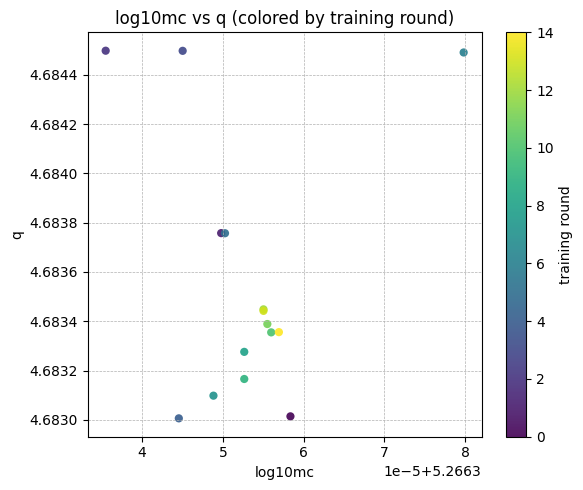

In [11]:
# 1) sigmas and sigmas_unnorm vs training round
plt.figure(figsize=(8, 5))
plt.plot(rounds, sig_arr, marker='o', label='sigma (normalized)')
plt.plot(rounds, sig_unnorm_arr, marker='x', label='sigma (unnormalized)')
plt.xlabel('Training round')
plt.ylabel('Residual (sigma)')
plt.yscale('log')
plt.title('ROM residuals during greedy training')
plt.grid(True, which='both', ls='--', lw=0.5)
plt.legend()
plt.tight_layout()
plt.savefig('rom_sigmas_vs_round.png', dpi=150)
plt.close()
# 2) scatter of log10mc_values vs q_values colored by sigmas
plt.figure(figsize=(6, 5))

idx = np.arange(log10mc_arr.shape[0])
norm = plt.Normalize(vmin=idx.min(), vmax=idx.max())
cmap = 'viridis'
# remaining points, marker 'o'
sc2 = plt.scatter(
    log10mc_arr,
    q_arr,
    c=idx,
    cmap=cmap,
    norm=norm,
    s=35,
    marker='o',
    edgecolors='none',
    alpha=0.9,
)

cbar = plt.colorbar(sc2)
cbar.set_label('training round')
plt.xlabel('log10mc')
plt.ylabel('q')
plt.title('log10mc vs q (colored by training round)')
plt.grid(True, ls='--', lw=0.5)
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, 'rom_log10mc_q_colored_by_training_round.png'), dpi=150)
plt.show()
plt.close()

In [12]:
torch.real(rom.basis).dtype

torch.float32

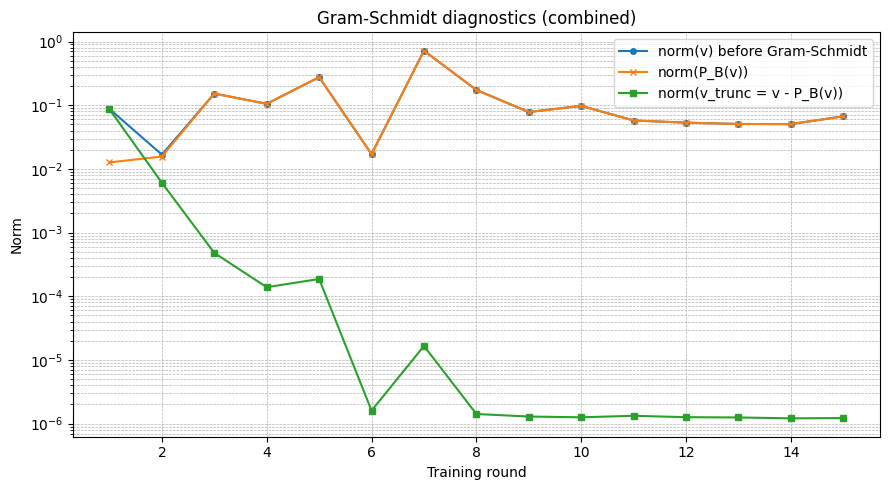

In [13]:
# 3) diagnose Gram-Schmidt norms
gs_diagnose = rom.training_diagnostics["gs_diagnose"]
norm_original = np.array(gs_diagnose["norm_v_original"], dtype=float)
norm_proj = np.array(gs_diagnose["norm_projection"], dtype=float)
norm_v_trunc = np.array(gs_diagnose["norm_v_trunc"], dtype=float)
rounds_o = np.arange(1, len(norm_original) + 1)
rounds_p = np.arange(1, len(norm_proj) + 1)
rounds_t = np.arange(1, len(norm_v_trunc) + 1)

plt.figure(figsize=(9, 5))
ax = plt.gca()
ax.plot(rounds_o, norm_original, marker='o', linestyle='-', markersize=4, label='norm(v) before Gram-Schmidt')
ax.plot(rounds_p, norm_proj,    marker='x', linestyle='-', markersize=4, label='norm(P_B(v))')
ax.plot(rounds_t, norm_v_trunc, marker='s', linestyle='-', markersize=4, label='norm(v_trunc = v - P_B(v))')

ax.set_xlabel('Training round')
ax.set_ylabel('Norm')
ax.set_yscale('log')
ax.set_title('Gram-Schmidt diagnostics (combined)')
ax.grid(True, which='both', ls='--', lw=0.5)
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, 'gs_norms_combined.png'), dpi=150)
plt.show()
plt.close()

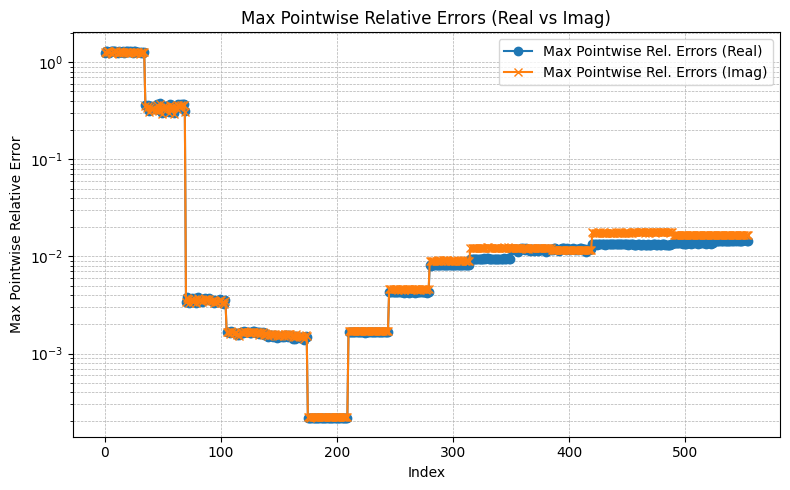

In [17]:
max_relerr_real = rom.training_diagnostics["max_pointwise_relerrors_real"]
max_relerr_imag = rom.training_diagnostics["max_pointwise_relerrors_imag"]
plt.figure(figsize=(8, 5))
plt.plot(max_relerr_real, label='Max Pointwise Rel. Errors (Real)', marker='o')
plt.plot(max_relerr_imag, label='Max Pointwise Rel. Errors (Imag)', marker='x')
plt.yscale('log')
plt.xlabel('Index')
plt.ylabel('Max Pointwise Relative Error')
plt.title('Max Pointwise Relative Errors (Real vs Imag)')
plt.grid(True, which='both', ls='--', lw=0.5)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# max_relerr_imag

[1.2755074501037598,
 1.2517839670181274,
 1.2876079082489014,
 1.2876635789871216,
 1.2671345472335815,
 1.2381497621536255,
 1.2152998447418213,
 1.2702913284301758,
 1.2586652040481567,
 1.2929834127426147,
 1.2917507886886597,
 1.282857060432434,
 1.2509626150131226,
 1.293018102645874,
 1.2612054347991943,
 1.2653175592422485,
 1.247613549232483,
 1.2725653648376465,
 1.278476357460022,
 1.2748451232910156,
 1.237477421760559,
 1.2662757635116577,
 1.2634488344192505,
 1.2348415851593018,
 1.2851512432098389,
 1.2819907665252686,
 1.231575846672058,
 1.252607822418213,
 1.2748298645019531,
 1.2699415683746338,
 1.2034931182861328,
 1.264644742012024,
 1.2453267574310303,
 1.2789617776870728,
 1.2738806009292603,
 0.3542705774307251,
 0.3372156023979187,
 0.3530152440071106,
 0.30984753370285034,
 0.3489457070827484,
 0.3254442512989044,
 0.3264569640159607,
 0.3265573978424072,
 0.3214321732521057,
 0.3185070753097534,
 0.3582823574542999,
 0.32296624779701233,
 0.3148554861545563

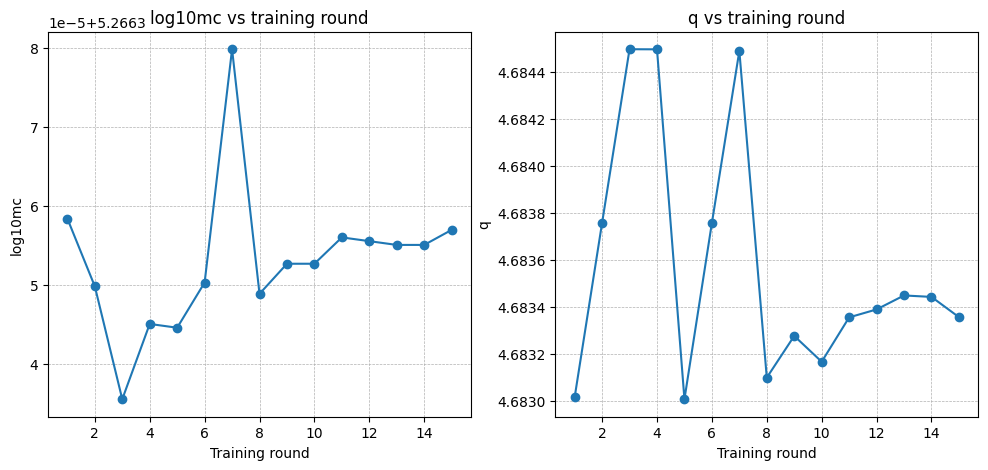

In [16]:
### plot also the q value and the chirp mass value vs training round for both roms: 
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(rounds, log10mc_arr, marker='o', label='New ROM')
#plt.plot(round_old, log10mc_values_old, marker='x', label='Old ROM')
plt.xlabel('Training round')
plt.ylabel('log10mc')
plt.title('log10mc vs training round')
plt.grid(True, ls='--', lw=0.5)
plt.subplot(1, 2, 2)
plt.plot(rounds, q_arr, marker='o', label='New ROM')
#plt.plot(round_old, q_values_old, marker='x', label='Old ROM')
plt.xlabel('Training round')
plt.ylabel('q')
plt.title('q vs training round')
plt.grid(True, ls='--', lw=0.5)
plt.savefig(os.path.join(plot_dir, 'rom_log10mc_q_vs_training_round.png'), dpi=150)
plt.show()
plt.close()


matrix shape: (7, 7)
abs stats -> min: 1.536e-08, max: 1.000e+00, mean: 1.430e-01, std: 3.499e-01
real part stats -> min: -2.778e-04, max: 1.000e+00, mean: 1.429e-01, std: 3.499e-01
imag part stats -> min: -1.089e-03, max: 1.089e-03, mean: 0.000e+00, std: 2.729e-04


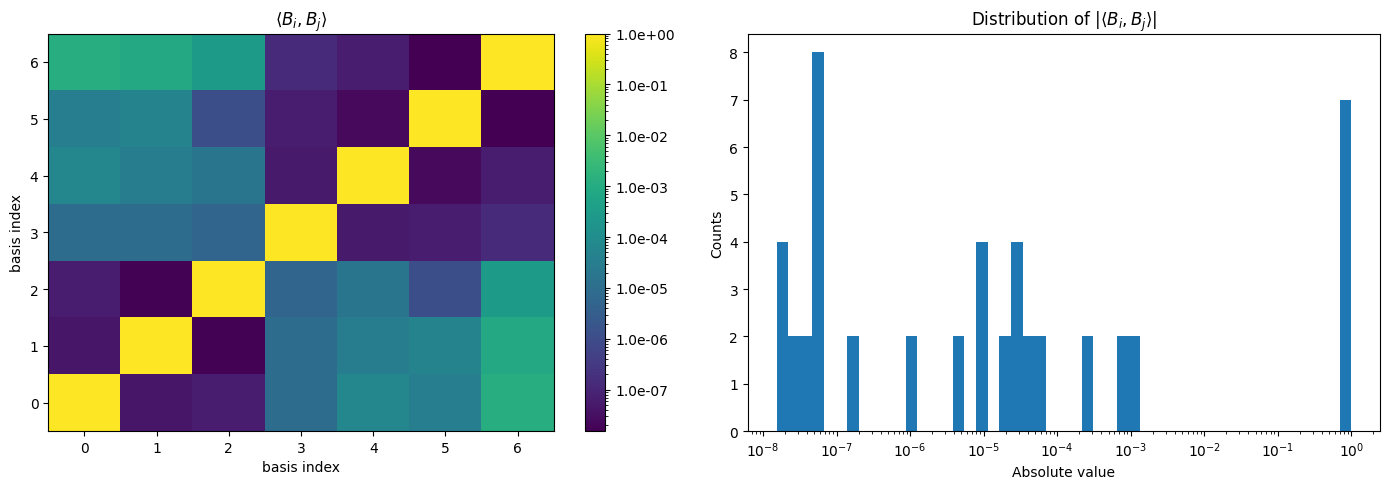

In [192]:
from matplotlib.colors import LogNorm
gram_matrix = rom.basis.conj() @ rom.basis.T
arr = gram_matrix.cpu().numpy()  # complex np array
abs_arr = np.abs(arr)
flat = abs_arr.ravel()

print(f"matrix shape: {arr.shape}")
print("abs stats -> min: {:.3e}, max: {:.3e}, mean: {:.3e}, std: {:.3e}".format(flat.min(), flat.max(), flat.mean(), flat.std()))
print("real part stats -> min: {:.3e}, max: {:.3e}, mean: {:.3e}, std: {:.3e}".format(arr.real.min(), arr.real.max(), arr.real.mean(), arr.real.std()))
print("imag part stats -> min: {:.3e}, max: {:.3e}, mean: {:.3e}, std: {:.3e}".format(arr.imag.min(), arr.imag.max(), arr.imag.mean(), arr.imag.std()))

fig, ax = plt.subplots(1, 2, figsize=(14, 5))



# 1) image of log10(abs(matrix))
vmin = abs_arr[abs_arr > 0].min()
vmax = abs_arr.max()

im = ax[0].imshow(
    abs_arr,
    origin='lower',
    cmap='viridis',
    aspect='auto',
    norm=LogNorm(vmin=vmin, vmax=vmax)
)

ax[0].set_title(r'$\langle B_i, B_j \rangle$')
ax[0].set_xlabel('basis index')
ax[0].set_ylabel('basis index')

plt.colorbar(im, ax=ax[0], format=plt.FuncFormatter(lambda x, _: f"{x:.1e}"))
# 2) flattened values: histogram of absolute values , with log scale on x axis and bins logspaced 
ax[1].hist(flat, bins=np.logspace(np.log10(flat.min()+1e-20), np.log10(flat.max()+1e-5), 50))
ax[1].set_xscale('log')
ax[1].set_xlabel('Absolute value')
ax[1].set_ylabel('Counts')
ax[1].set_title(r'Distribution of $|\langle B_i, B_j \rangle|$')

plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "rom_gram_matrix_diagnostics.png"), dpi=300)
plt.show()
plt.close(fig)




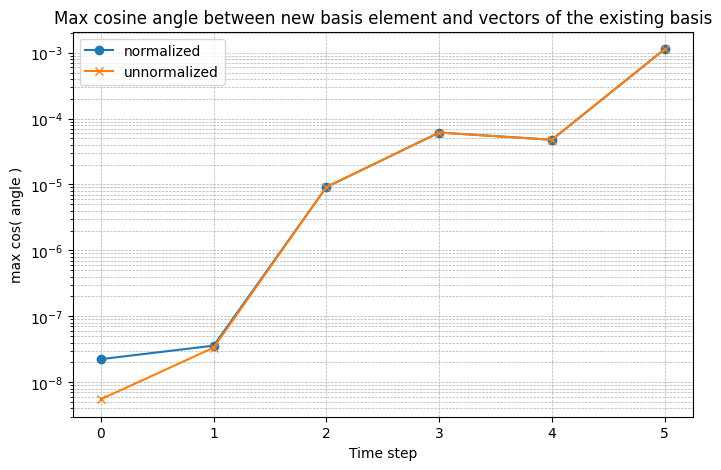

In [193]:
cosine_angles_normalised = gs_diagnose["max_cosine_angle_normalised"]
cosine_angles_unnormalised = gs_diagnose["max_cosine_angle_unnormalised"]

plt.figure(figsize=(8, 5))
plt.plot(cosine_angles_normalised, marker='o', label='normalized')
plt.plot(cosine_angles_unnormalised, marker='x', label='unnormalized')
plt.yscale("log")
plt.xlabel('Time step')
plt.ylabel('max cos( angle )')
plt.legend()
plt.title('Max cosine angle between new basis element and vectors of the existing basis')
plt.savefig(os.path.join(plot_dir, "rom_gram_schmidt_cosine_angles.png"), dpi=300)
plt.grid(True, which='both', ls='--', lw=0.5)
plt.show()

In [194]:
### assessing reconstruction error on training set, as function of number of basis elements used. 
from torch.utils.data import Subset, DataLoader
from pembhb.data import MBHBDataModule
import importlib 
pembhb_data = importlib.import_module("pembhb.data")
importlib.reload(pembhb_data)

<module 'pembhb.data' from '/u/g/gpuleo/pembhb/src/pembhb/data.py'>

In [195]:
datamodule = MBHBDataModule(data_filename, batch_size=400, num_workers=2, cache_in_memory=False)
datamodule.setup(stage="fit")
dataloader = datamodule.train_dataloader(shuffle=False)
freqs = datamodule.get_freqs()
print("loaded datamodule from file")

loaded datamodule from file


In [196]:
rom_basis_full = rom.basis.clone()
rom_basis_full.shape

torch.Size([7, 8192])

In [198]:
rom.basis = rom_basis_full

In [199]:
max_rel_err_wave = 0.0
for batch in dataloader:
    data_fd = batch["wave_fd"]+batch["noise_fd"]  # shape (B, 2*ch, n_freq),  has amplitude and phase
    wave_fd = batch["wave_fd"]  # shape (B, ch, n_freq), contains complex numbers 
    params = batch["source_parameters"][:,:2]  # shape (B, 2)
    # apply the ROM on clean waveforms
    coeffs_wave = rom.compress(wave_fd)
    #coeffs_wave[:,3:] = 0
    amplitudes_wave = torch.abs(wave_fd)
    amplitudes_data = torch.abs(data_fd)
    #logamplitudes_wave = torch.log(torch.abs(wave_fd)+1e-33)
    phases_wave = torch.angle(wave_fd)
    phases_data = torch.angle(data_fd)
    reconstructed_wave = rom.reconstruct(coeffs_wave)

    coeffs_data = rom.compress(data_fd)
    reconstructed_data = rom.reconstruct(coeffs_data)

    # reimplement with few lines what happens in building the rom. 
    ######## ### START COPIED ROM CODE ###########
    bsize = batch['wave_fd'].shape[0]

    _IR_wave_out = batch['wave_fd'].reshape(bsize, -1).to(rom.device)

    # normalise  and center, then project and compute residuals
    _IR_norm_wave_in = (_IR_wave_out - rom.mean_vec) / rom.global_scale_factor  # shape (B_size, N_dim)
    _IR_proj_in = rom._project_batch(_IR_norm_wave_in)
    _IR_residual_in = _IR_norm_wave_in - _IR_proj_in

    # reconstruct in original space
    _IR_reconstruction_out = _IR_proj_in * rom.global_scale_factor + rom.mean_vec
    # compute residuals in original space
    _IR_residual_out = _IR_wave_out - _IR_reconstruction_out
    r = (_IR_norm_wave_in - _IR_proj_in) / _IR_norm_wave_in.norm(dim=1, keepdim=True)
    #r_unnorm = wave_fd_batch - _IR_proj_in

    norms = (r.abs() ** 2).sum(dim=1)



    ############# END COPIED ROM CODE ###########

    reconstructed_amplitudes  = torch.abs(reconstructed_wave)
    reconstructed_phases_wave = torch.angle(reconstructed_wave)

    reconstructed_amplitudes_data  = torch.abs(reconstructed_data)
    reconstructed_phases_data = torch.angle(reconstructed_data)

    relative_errors_wave = np.linalg.norm(reconstructed_wave-wave_fd, axis=(1,2))/ np.linalg.norm(wave_fd, axis=(1,2))
    max_rel_err_wave = max(max_rel_err_wave, np.max(relative_errors_wave))
    relative_errors_data = np.linalg.norm(reconstructed_data-data_fd, axis=(1,2))/ np.linalg.norm(data_fd, axis=(1,2))

    relative_errors_rec_data_wrt_wave = np.linalg.norm(reconstructed_data - wave_fd, axis=(1,2))/ np.linalg.norm(wave_fd, axis=(1,2))
    # residual_wave = torch.abs(reconstructed_wave  - wave_fd)
    # residual_relative_wave = torch.linalg.norm(reconstructed_wave  - wave_fd)/ torch.linalg.norm(wave_fd, dim=(1,2), keepdim=True)
    # residual_relative_data = torch.linalg.norm(reconstructed_data  - data_fd)/ torch.linalg.norm(data_fd, dim=(1,2), keepdim=True)

    break

print(f"max relative error on waveforms in training set: {max_rel_err_wave:.3e}")

max relative error on waveforms in training set: 2.427e-05


In [200]:
# these are the same quantity computed in two different ways
flat_reconstruction = reconstructed_wave.reshape(reconstructed_wave.shape[0], -1)
x = flat_reconstruction - _IR_reconstruction_out
## x should be exactly zero 
max_diff = x.abs().max().item()
print(f"max difference between custom reconstruction and ROM reconstruction: {max_diff:.3e}")

max difference between custom reconstruction and ROM reconstruction: 0.000e+00


In [201]:
# cosine_angles_normalised.shape

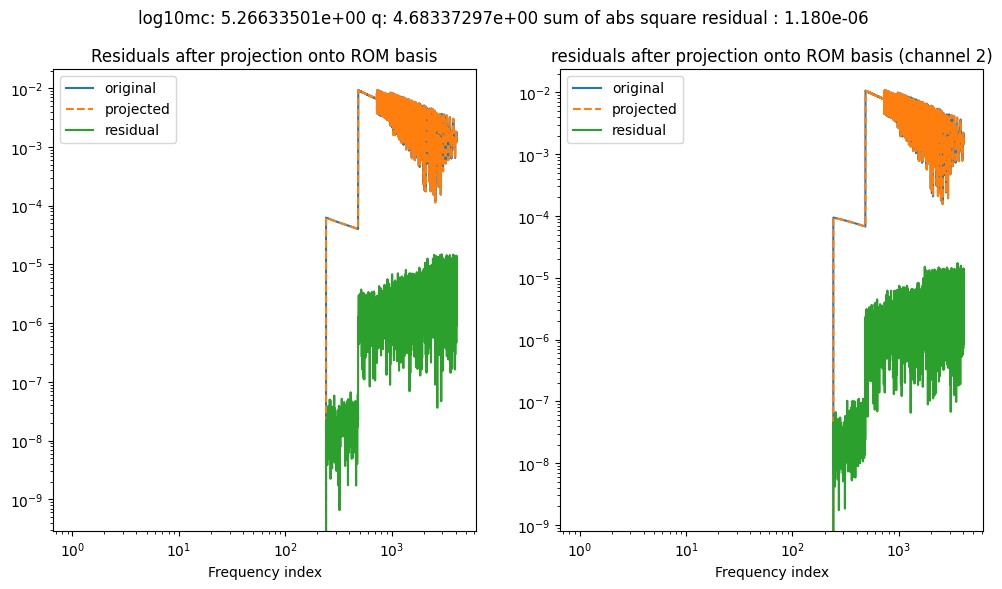

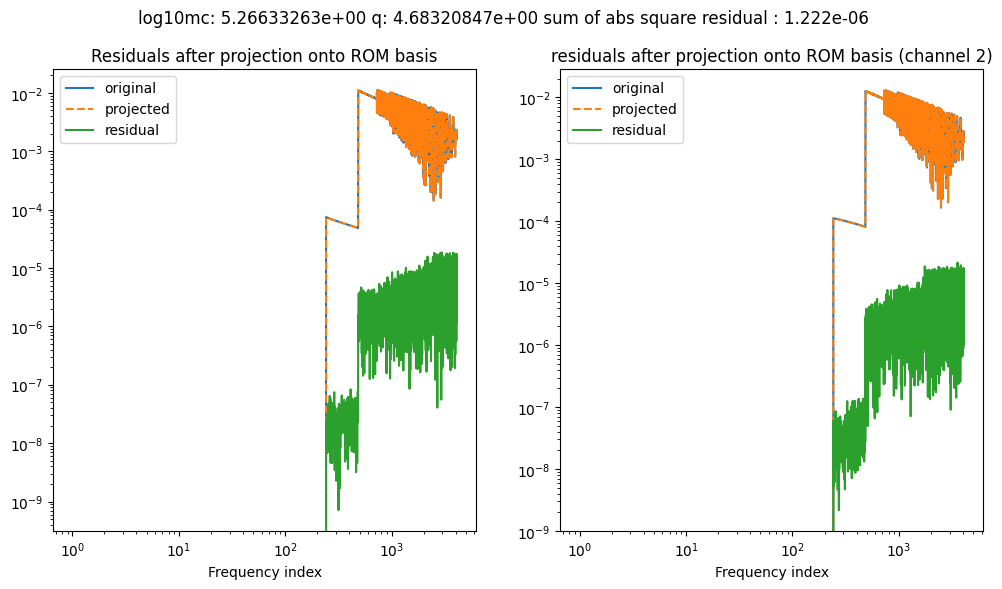

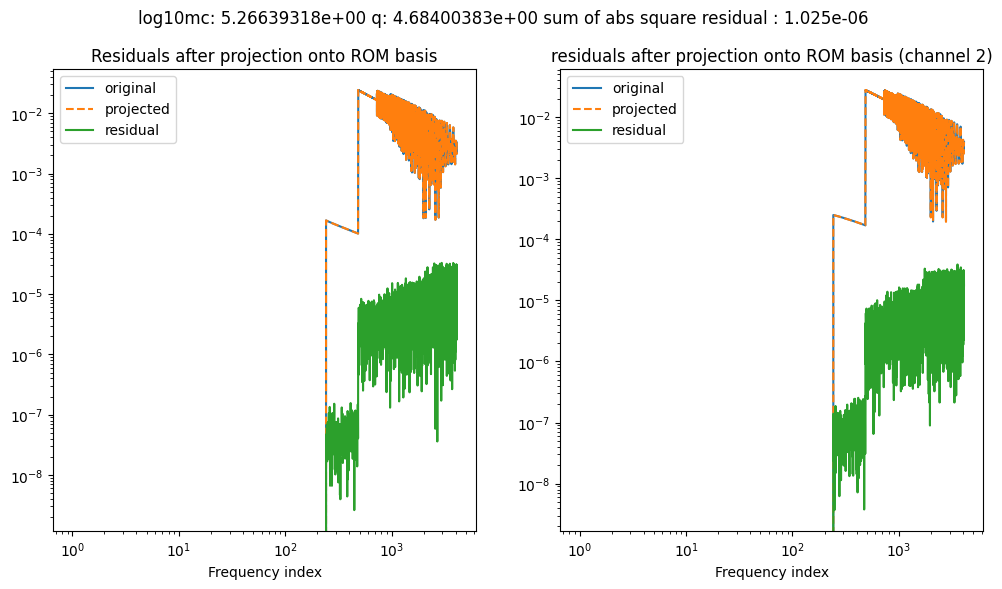

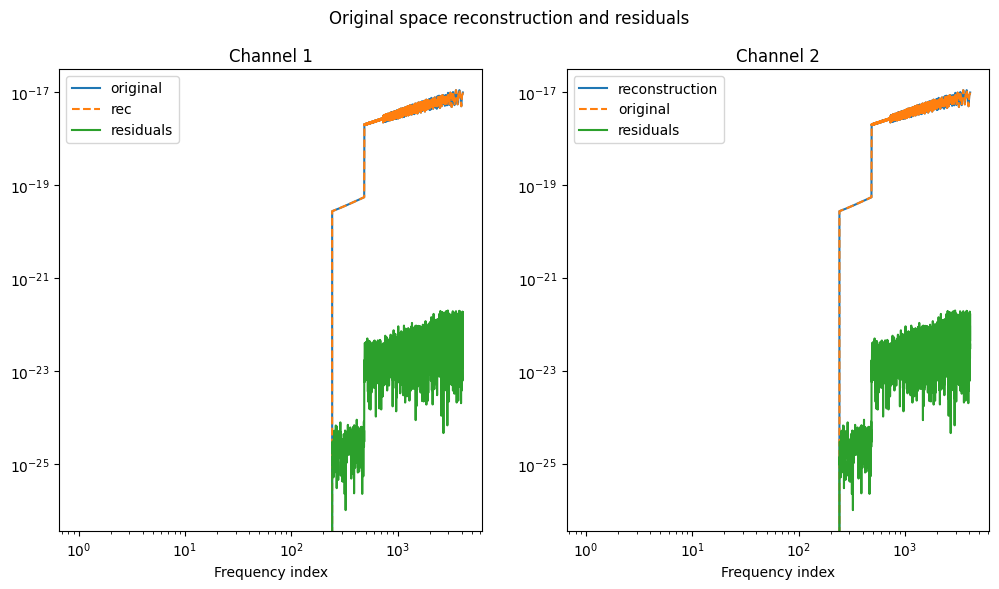

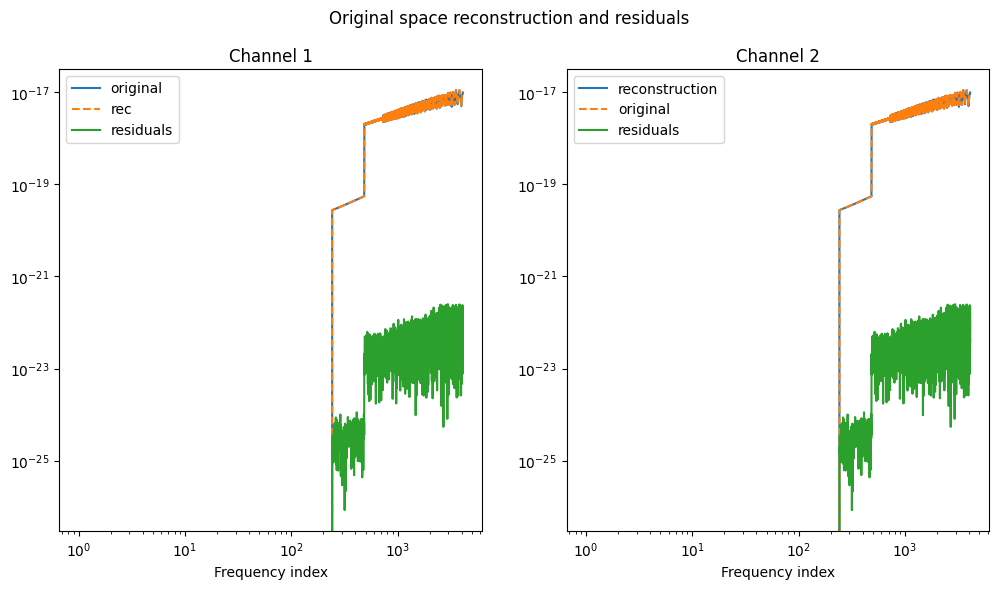

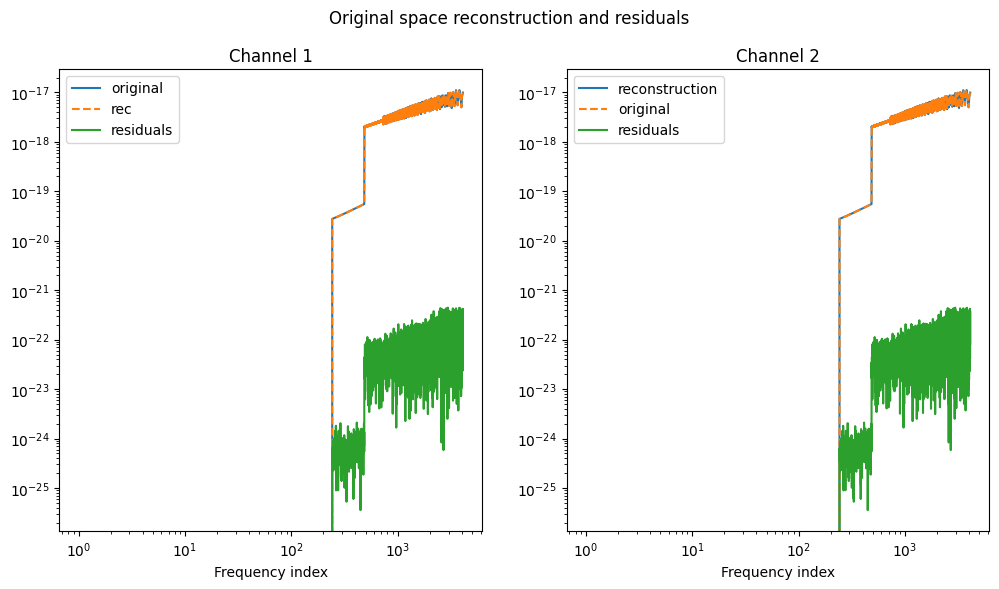

In [202]:
########### mimic the plots that happen within the ROM : 
for jj in range(min(3, bsize)):
    # on channel 1 and plot in_
    plt.figure(figsize=(12,6))
    plt.subplot(1,2,1)
    plt.plot(_IR_norm_wave_in[jj][:rom.n_freq].abs().cpu().numpy(), label="original")
    plt.plot(_IR_proj_in[jj][:rom.n_freq].abs().cpu().numpy(), label="projected", linestyle="--")
    plt.plot(_IR_residual_in[jj][:rom.n_freq].abs().cpu().numpy(), label=f"residual")
    _params = batch['source_parameters'][jj][:2].cpu().numpy()
    plt.suptitle(f"log10mc: {_params[0]:.8e} q: {_params[1]:.8e} sum of abs square residual : {norms[jj].item():.3e}")
    plt.title("channel 1: {norm:.3e}".format(norm=norms[jj].item()))
    # plt.plot(r[0][self.n_freq:], label=f"channel 2")
    plt.xlabel("Frequency index")
    plt.xscale("log")
    plt.yscale("log")
    plt.title("Residuals after projection onto ROM basis")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(_IR_norm_wave_in[jj][rom.n_freq:].abs().cpu().numpy(), label="original")
    plt.plot(_IR_proj_in[jj][rom.n_freq:].abs().cpu().numpy(), label="projected", linestyle="--")
    plt.plot(_IR_residual_in[jj][rom.n_freq:].abs().cpu().numpy(), label=f"residual")

    plt.title("residuals after projection onto ROM basis (channel 2)")
    plt.xlabel("Frequency index")
    plt.xscale("log")
    plt.yscale("log")
    plt.legend()
    #plt.savefig(os.path.join(rom.plot_dir_debug, f"residuals_epoch{rom.epoch}_batch{idx}_event{jj}.png"))

for jj in range(min(3, bsize)):
    plt.figure(figsize=(12,6))
    
    plt.subplot(1,2,1)
    plt.plot(_IR_wave_out[jj][:rom.n_freq].abs().cpu().numpy(), label="original")
    plt.plot(_IR_reconstruction_out[jj][:rom.n_freq].reshape(-1).abs().cpu().numpy(), label="rec", linestyle="--")
    plt.plot(_IR_residual_out[jj][:rom.n_freq].abs().cpu().numpy(), label="residuals")
    plt.xlabel("Frequency index")
    plt.xscale("log")
    plt.yscale("log")
    plt.suptitle("Original space reconstruction and residuals")
    plt.legend()
    plt.title("Channel 1")

    plt.subplot(1,2,2)
    plt.plot(_IR_wave_out[jj][:rom.n_freq].abs().cpu().numpy(), label="reconstruction")
    plt.plot(_IR_reconstruction_out[jj][:rom.n_freq].reshape(-1).abs().cpu().numpy(), label="original", linestyle="--")
    plt.plot(_IR_residual_out[jj][:rom.n_freq].abs().cpu().numpy(), label="residuals")
    plt.xlabel("Frequency index")
    plt.xscale("log")
    plt.yscale("log")
    plt.title("Channel 2")
    plt.legend()
    #plt.savefig(os.path.join(self.plot_dir_debug, f"{self.epoch}_batch{idx}_event{jj}.png"))


In [203]:
relerr_anotherway = np.linalg.norm(_IR_residual_out, axis=1)/ np.linalg.norm(_IR_wave_out, axis=1)
print(torch.max(torch.tensor(relerr_anotherway)))
print(torch.max(_IR_residual_in.abs()))

tensor(2.42685692e-05)
tensor(4.77965041e-05)


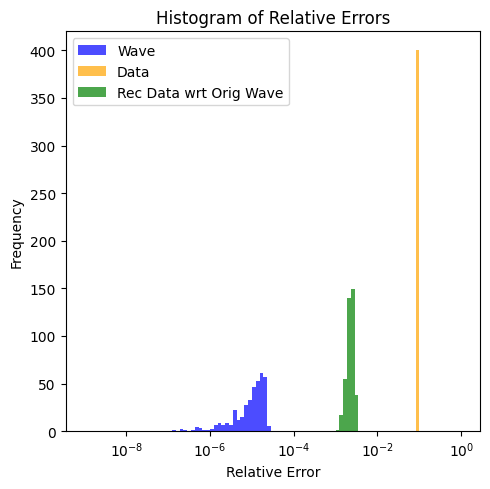

In [204]:
# make a histogram of relative_errors_wave and relative_errors_data
plt.figure(figsize=(5, 5))
bins = np.logspace(-9, 0, 100)
plt.hist(relative_errors_wave, bins=bins, alpha=0.7, label='Wave', color='blue')
plt.hist(relative_errors_data, bins=bins, alpha=0.7, label='Data', color='orange')
plt.hist(relative_errors_rec_data_wrt_wave, bins=bins, alpha=0.7, label='Rec Data wrt Orig Wave', color='green')
plt.xscale('log')
plt.xlabel('Relative Error')
plt.ylabel('Frequency')
plt.title('Histogram of Relative Errors')
plt.legend()

plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "rom_reconstruction_error_histogram.png"), dpi=300)
plt.show()


In [30]:
mean_relerr_datawave = np.mean(relative_errors_rec_data_wrt_wave)

In [17]:
# # Create a 2x3 grid of subplots for amplitude plots
# fig, ax = plt.subplots(2, 3, figsize=(15, 10))
# for i in range(3):  # Iterate over events
#     for channel in range(wave_fd.shape[1]):  # Iterate over channels
#         ax[channel, i].plot(freqs, torch.abs(wave_fd[i, channel]).cpu().numpy(), label=f'Original Waveform (Channel {channel + 1})')
#         ax[channel, i].plot(freqs, torch.abs(reconstructed_wave[i, channel]).cpu().numpy(), label=f'Reconstructed Waveform (Channel {channel + 1})')
#         ax[channel, i].set_title(f'Waveform {i + 1} - Channel {channel + 1}')
#         ax[channel, i].set_xlabel('Frequency (Hz)')
#         ax[channel, i].set_ylabel('Amplitude (Log Scale)')
#         ax[channel, i].set_xscale('log')
#         ax[channel, i].set_yscale('log')
#         ax[channel, i].legend()
#         ax[channel, i].grid(True, which='both', ls='--', lw=0.5)
# plt.tight_layout()

# # Create a 2x3 grid of subplots for phase plots
# fig, ax = plt.subplots(2, 3, figsize=(15, 10))
# for i in range(3):  # Iterate over events
#     for channel in range(wave_fd.shape[1]):  # Iterate over channels
#         ax[channel, i].plot(freqs, torch.angle(wave_fd[i, channel]).cpu().numpy(), label=f'Original Waveform (Channel {channel + 1})')
#         ax[channel, i].plot(freqs, torch.angle(reconstructed_wave[i, channel]).cpu().numpy(), label=f'Reconstructed Waveform (Channel {channel + 1})')
#         ax[channel, i].set_title(f'Waveform {i + 1} - Channel {channel + 1}')
#         ax[channel, i].set_xlabel('Frequency (Hz)')
#         ax[channel, i].set_ylabel('Phase (Radians)')
#         ax[channel, i].set_xscale('log')
#         ax[channel, i].set_yscale('linear')
#         ax[channel, i].legend()
#         ax[channel, i].grid(True, which='both', ls='--', lw=0.5)
# plt.tight_layout()

plt.show()



In [183]:
####### study distance in different representation spaces. 
# Flatten the last two dimensions to compute distances
reconstructed_wave_flat = reconstructed_wave.view(reconstructed_wave.shape[0], -1)
wave_fd_flat = wave_fd.view(wave_fd.shape[0], -1)


# Compute the Euclidean distance matrix for reconstructed_wave
diff_reconstructed = reconstructed_wave_flat.unsqueeze(1) - reconstructed_wave_flat.unsqueeze(0)
dist_matrix_reconstructed = torch.sqrt(torch.sum(diff_reconstructed.conj() * diff_reconstructed, dim=-1).real)

# Compute the Euclidean distance matrix for wave_fd
diff_wave_fd = wave_fd_flat.unsqueeze(1) - wave_fd_flat.unsqueeze(0)
dist_matrix_wave_fd = torch.sqrt(torch.sum(diff_wave_fd.conj() * diff_wave_fd, dim=-1).real)

# Compute the Euclidean dist mat for coeffs_wave
diff_coeffs = coeffs_wave.unsqueeze(1) - coeffs_wave.unsqueeze(0)
dist_matrix_coeffs = torch.sqrt(torch.sum(diff_coeffs.conj() * diff_coeffs, dim=-1).real)

# Euclidean distance matrices for data_fd : 
reconstructed_data_flat = reconstructed_data.view(reconstructed_data.shape[0], -1)
data_fd_flat = data_fd.view(data_fd.shape[0], -1)

# Euclidean distance matrix for parameters 
dist_matrix_params = torch.sqrt(torch.sum(( params.unsqueeze(1) - params.unsqueeze(0))**2, dim=-1))



diff_reconstructed_data = reconstructed_data_flat.unsqueeze(1) - reconstructed_data_flat.unsqueeze(0)
dist_matrix_reconstructed_data = torch.sqrt(torch.sum(diff_reconstructed_data.conj() * diff_reconstructed_data, dim=-1).real)
diff_data_fd = data_fd_flat.unsqueeze(1) - data_fd_flat.unsqueeze(0)
dist_matrix_data_fd = torch.sqrt(torch.sum(diff_data_fd.conj() * diff_data_fd, dim=-1).real)
diff_coeffs_data = coeffs_data.unsqueeze(1) - coeffs_data.unsqueeze(0)
dist_matrix_coeffs_data = torch.sqrt(torch.sum(diff_coeffs_data.conj() * diff_coeffs_data, dim=-1).real)

# Extract the upper triangular part of the distance matrices
upper_tri_reconstructed = torch.triu(dist_matrix_reconstructed, diagonal=1)
upper_tri_wave_fd = torch.triu(dist_matrix_wave_fd, diagonal=1)
upper_tri_coeffs = torch.triu(dist_matrix_coeffs, diagonal=1)
upper_tri_reconstructed_data = torch.triu(dist_matrix_reconstructed_data, diagonal=1)
upper_tri_data_fd = torch.triu(dist_matrix_data_fd, diagonal=1)
upper_tri_coeffs_data = torch.triu(dist_matrix_coeffs_data, diagonal=1)
upper_tri_params = torch.triu(dist_matrix_params, diagonal=1)


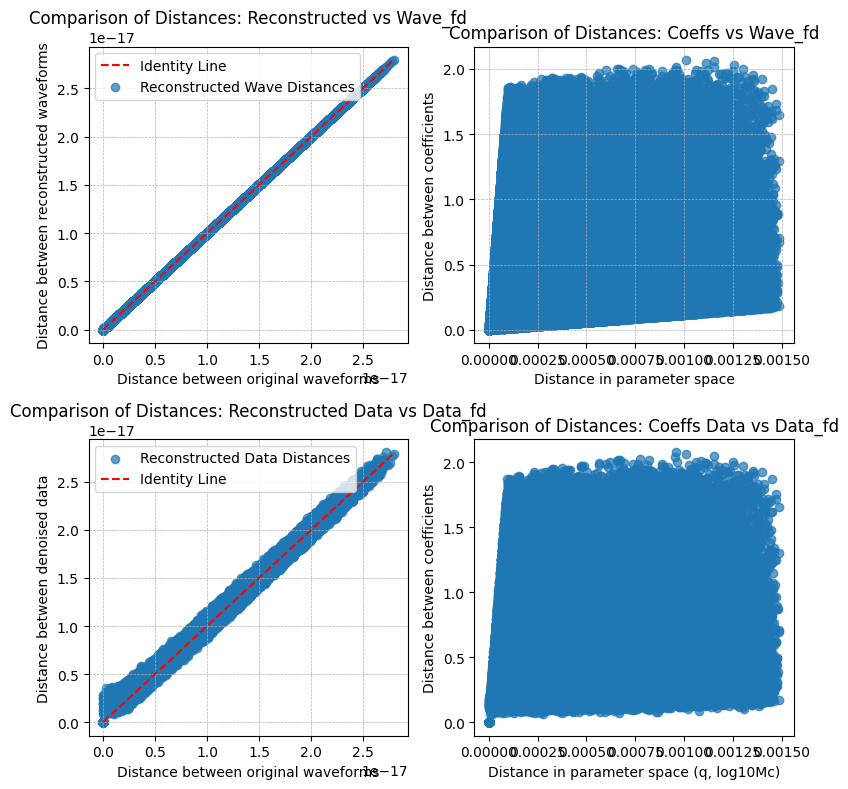

In [184]:
# Plot the upper triangular distances for reconstructed_wave and wave_fd
plt.figure(figsize=(8, 8))
# plot the identity line
plt.subplot(2, 2, 1)
plt.plot([0, upper_tri_wave_fd.max().item()], [0, upper_tri_wave_fd.max().item()], 'r--', label='Identity Line')
plt.scatter(upper_tri_wave_fd.cpu().numpy(), upper_tri_reconstructed.cpu().numpy(), label='Reconstructed Wave Distances', alpha=0.7)
plt.xlabel('Distance between original waveforms')
plt.ylabel('Distance between reconstructed waveforms')
plt.title('Comparison of Distances: Reconstructed vs Wave_fd')
plt.legend()
plt.grid(True, which='both', ls='--', lw=0.5)
plt.subplot(2, 2, 2)
plt.scatter(upper_tri_params.cpu().numpy(), upper_tri_coeffs.cpu().numpy(), label='Coefficients Distances', alpha=0.7)
plt.xlabel('Distance in parameter space')
plt.ylabel('Distance between coefficients')
plt.title('Comparison of Distances: Coeffs vs Wave_fd')
plt.grid(True, which='both', ls='--', lw=0.5)

plt.subplot(2, 2, 3) 
plt.scatter(upper_tri_wave_fd.cpu().numpy(), upper_tri_reconstructed_data.cpu().numpy(), label='Reconstructed Data Distances', alpha=0.7)
plt.plot([0, upper_tri_wave_fd.max().item()], [0, upper_tri_wave_fd.max().item()], 'r--', label='Identity Line')
plt.xlabel('Distance between original waveforms')
plt.ylabel('Distance between denoised data')
plt.title('Comparison of Distances: Reconstructed Data vs Data_fd')
plt.legend()
plt.grid(True, which='both', ls='--', lw=0.5)

plt.subplot(2,2,4)
plt.scatter(upper_tri_params.cpu().numpy(), upper_tri_coeffs_data.cpu().numpy(), label='Coefficients Data Distances', alpha=0.7)
plt.xlabel('Distance in parameter space (q, log10Mc)')
plt.ylabel('Distance between coefficients')
plt.title('Comparison of Distances: Coeffs Data vs Data_fd')

plt.tight_layout()

plt.savefig(os.path.join(plot_dir, "rom_distance_matrices_comparison.png"), dpi=300)
plt.show()
plt.close()


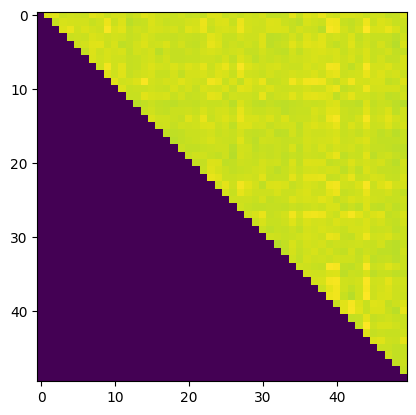

In [23]:
plt.imshow(upper_tri_data_fd.cpu().numpy())

In [21]:
ii, jj = torch.where(upper_tri_data_fd == 0 )
for i, j in zip(ii, jj): 
    if i != j:
        print(i, j)

tensor(1) tensor(0)
tensor(2) tensor(0)
tensor(2) tensor(1)
tensor(3) tensor(0)
tensor(3) tensor(1)
tensor(3) tensor(2)
tensor(4) tensor(0)
tensor(4) tensor(1)
tensor(4) tensor(2)
tensor(4) tensor(3)
tensor(5) tensor(0)
tensor(5) tensor(1)
tensor(5) tensor(2)
tensor(5) tensor(3)
tensor(5) tensor(4)
tensor(6) tensor(0)
tensor(6) tensor(1)
tensor(6) tensor(2)
tensor(6) tensor(3)
tensor(6) tensor(4)
tensor(6) tensor(5)
tensor(7) tensor(0)
tensor(7) tensor(1)
tensor(7) tensor(2)
tensor(7) tensor(3)
tensor(7) tensor(4)
tensor(7) tensor(5)
tensor(7) tensor(6)
tensor(8) tensor(0)
tensor(8) tensor(1)
tensor(8) tensor(2)
tensor(8) tensor(3)
tensor(8) tensor(4)
tensor(8) tensor(5)
tensor(8) tensor(6)
tensor(8) tensor(7)
tensor(9) tensor(0)
tensor(9) tensor(1)
tensor(9) tensor(2)
tensor(9) tensor(3)
tensor(9) tensor(4)
tensor(9) tensor(5)
tensor(9) tensor(6)
tensor(9) tensor(7)
tensor(9) tensor(8)
tensor(10) tensor(0)
tensor(10) tensor(1)
tensor(10) tensor(2)
tensor(10) tensor(3)
tensor(10) tenso

In [32]:
# intrinsic dimension computation given distance matrix
def intrinsic_dimension(distance_matrix):
    N = distance_matrix.shape[0]
    distances_sorted = np.sort(distance_matrix, axis=1)

    mu = distances_sorted[:,2]/distances_sorted[:,1]
    mu = np.sort(mu)
    intrinsic_dim = N/(np.sum(np.log(mu)))
    return intrinsic_dim

In [33]:
id_original = intrinsic_dimension(dist_matrix_wave_fd)
id_reconstructed = intrinsic_dimension(dist_matrix_reconstructed)
id_coeffs = intrinsic_dimension(dist_matrix_coeffs)
id_reconstructed_data = intrinsic_dimension(dist_matrix_reconstructed_data)
id_data_fd = intrinsic_dimension(dist_matrix_data_fd)
id_coeffs_data = intrinsic_dimension(dist_matrix_coeffs_data)
id_params = intrinsic_dimension(dist_matrix_params)


/tmp/ipykernel_3649822/267515645.py:6: RuntimeWarning: divide by zero encountered in divide
  mu = distances_sorted[:,2]/distances_sorted[:,1]


In [34]:
# print all of them : 
print(f"Intrinsic Dimension - Original Waveforms: {id_original:.3f}")
print(f"Intrinsic Dimension - Reconstructed Waveforms: {id_reconstructed:.3f}")
print(f"Intrinsic Dimension - Coefficients: {id_coeffs:.3f}")
print(f"Intrinsic Dimension - Reconstructed Data: {id_reconstructed_data:.3f}")
print(f"Intrinsic Dimension - Data with noise: {id_data_fd:.3f}")
print(f"Intrinsic Dimension - Coefficients Data: {id_coeffs_data:.3f}")
print(f"Intrinsic Dimension - Parameters (q, log10Mc): {id_params:.3f}")

Intrinsic Dimension - Original Waveforms: 1.809
Intrinsic Dimension - Reconstructed Waveforms: 1.809
Intrinsic Dimension - Coefficients: 1.810
Intrinsic Dimension - Reconstructed Data: 6.691
Intrinsic Dimension - Data with noise: 342.062
Intrinsic Dimension - Coefficients Data: 6.691
Intrinsic Dimension - Parameters (q, log10Mc): 0.000


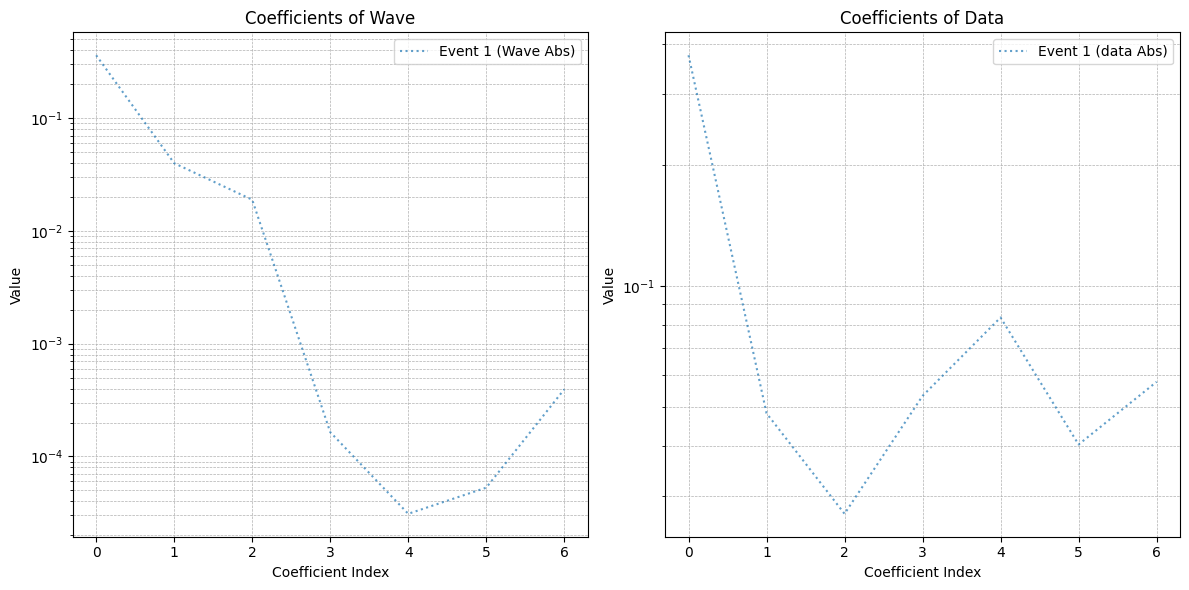

In [37]:
#  plot coeffs wave and coeffs data as function of their index 
plt.figure(figsize=(12, 6))

# Plot coeffs_wave as a function of their index
plt.subplot(1, 2, 1)
N_events = 1
for i in range(N_events):  # Iterate over events
    # plt.plot(range(coeffs_wave.shape[1]), coeffs_wave[i, :].real.cpu().numpy(), label=f'Event {i+1} (Real)', alpha=0.7)
    # plt.plot(range(coeffs_wave.shape[1]), coeffs_wave[i, :].imag.cpu().numpy(), linestyle='--', label=f'Event {i+1} (Imag)', alpha=0.7)
    plt.plot(range(coeffs_wave.shape[1]), coeffs_wave[i, :].abs().cpu().numpy(), linestyle=':', label=f'Event {i+1} (Wave Abs)', alpha=0.7)
plt.xlabel('Coefficient Index')
plt.ylabel('Value')
plt.yscale('log')
plt.title('Coefficients of Wave')
plt.legend()
plt.grid(True, which='both', ls='--', lw=0.5)

# Plot coeffs_data as a function of their index
plt.subplot(1, 2, 2)
for i in range(N_events):  # Iterate over events
    # plt.plot(range(coeffs_data.shape[1]), coeffs_data[i, :].real.cpu().numpy(), label=f'Event {i+1} (Real)', alpha=0.7)
    # plt.plot(range(coeffs_data.shape[1]), coeffs_data[i, :].imag.cpu().numpy(), linestyle='--', label=f'Event {i+1} (Imag)', alpha=0.7)
    plt.plot(range(coeffs_data.shape[1]), coeffs_data[i, :].abs().cpu().numpy(), linestyle=':', label=f'Event {i+1} (data Abs)', alpha=0.7)
plt.xlabel('Coefficient Index')
plt.ylabel('Value')
plt.yscale('log')
plt.title('Coefficients of Data')
plt.legend()
plt.grid(True, which='both', ls='--', lw=0.5)

plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "rom_coefficients_vs_index.png"), dpi=300)
plt.show()

In [103]:
# fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# # Plot for channel A (i=0)
# ax[0].plot(freqs, residual_wave[0, 0, :].numpy(), label='Channel A', color='blue')
# ax[0].plot(freqs, residual_wrong[ 0, :].numpy(), label='Residual wrt wrong waveform', color='red', linestyle='--')
# ax[0].set_title('Residual Wave - Channel A')
# ax[0].set_xlabel('Frequency (Hz)')
# ax[0].set_ylabel('Residual Amplitude')
# ax[0].set_xscale('log')
# ax[0].set_yscale('log')
# ax[0].grid(True, which='both', ls='--', lw=0.5)
# ax[0].legend()

# # Plot for channel E (i=1)
# ax[1].plot(freqs, residual_wave[0, 1, :].numpy(), label='Channel E', color='green')
# ax[1].plot(freqs, residual_wrong[1, :].numpy(), label='Residual wrt wrong waveform', color='red', linestyle='--')
# ax[1].set_title('Residual Wave - Channel E')
# ax[1].set_xlabel('Frequency (Hz)')
# ax[1].set_ylabel('Residual Amplitude')
# ax[1].set_xscale('log')
# ax[1].set_yscale('log')
# ax[1].grid(True, which='both', ls='--', lw=0.5)
# ax[1].legend()

# plt.tight_layout()
# plt.show()

In [ ]:
plt.plot()

In [104]:
# fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# # Plot for channel A (i=0)
# ax[0].plot(freqs, residual_relative_wave[0, 0, :].numpy(), label='Channel A', color='blue')
# ax[0].plot(freqs, residual_relative_wrong[0, :].numpy(), label='Residual wrt wrong waveform', color='red', linestyle='--')
# ax[0].set_title('Relative Residual Wave - Channel A')
# ax[0].set_xlabel('Frequency (Hz)')
# ax[0].set_ylabel('Relative Residual Amplitude')
# ax[0].set_xscale('log')
# ax[0].set_yscale('log')
# ax[0].grid(True, which='both', ls='--', lw=0.5)
# ax[0].legend()

# # Plot for channel E (i=1)
# ax[1].plot(freqs, residual_relative_wave[0, 1, :].numpy(), label='Channel E', color='green')
# ax[1].plot(freqs, residual_relative_wrong[1, :].numpy(), label='Residual wrt wrong waveform', color='red', linestyle='--')
# ax[1].set_title('Relative Residual Wave - Channel E')
# ax[1].set_xlabel('Frequency (Hz)')
# ax[1].set_ylabel('Relative Residual Amplitude')
# ax[1].set_xscale('log')
# ax[1].set_yscale('log')
# ax[1].grid(True, which='both', ls='--', lw=0.5)
# ax[1].legend()

# plt.tight_layout()
# plt.show()


mean of channel 0, event 0: -4.692e-21-1.634e-21j
 std: 5.990e-18
mean of channel 1, event 0: -1.035e-21+5.635e-21j
 std: 7.157e-18
mean of channel 0, event 1: -4.704e-21-1.593e-21j
 std: 5.990e-18
mean of channel 1, event 1: -9.864e-22+5.641e-21j
 std: 7.157e-18
mean of channel 0, event 2: -4.390e-21-2.378e-21j
 std: 5.991e-18
mean of channel 1, event 2: -1.937e-21+5.436e-21j
 std: 7.158e-18
mean of channel 0, event 3: -4.393e-21-2.373e-21j
 std: 5.991e-18
mean of channel 1, event 3: -1.931e-21+5.438e-21j
 std: 7.158e-18


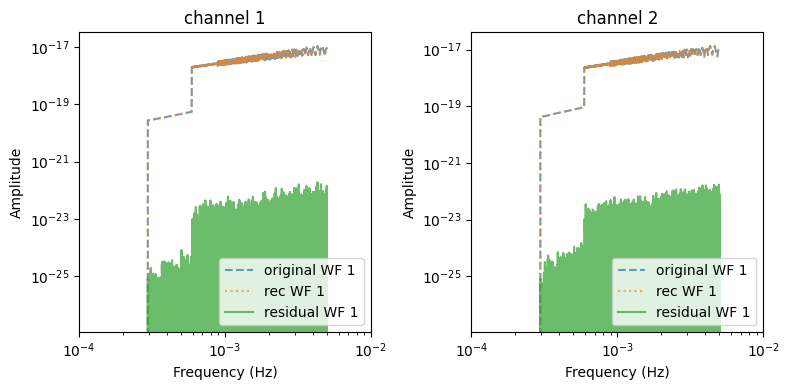

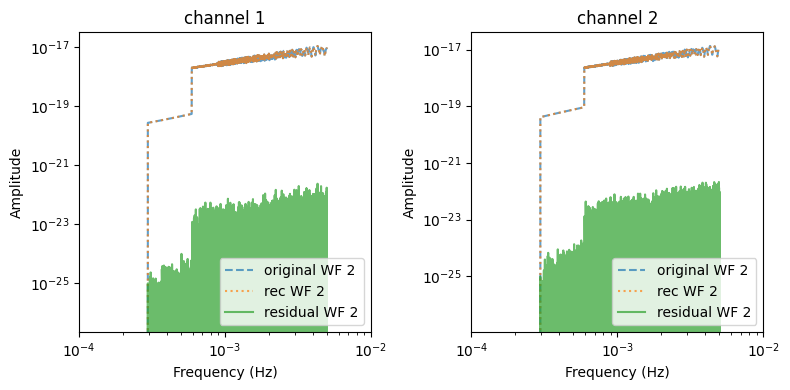

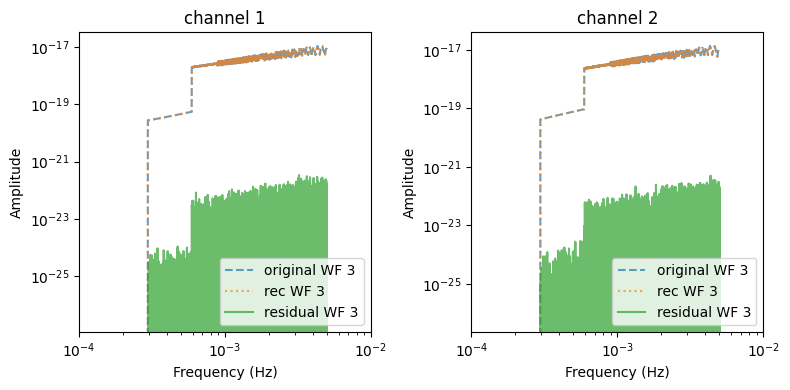

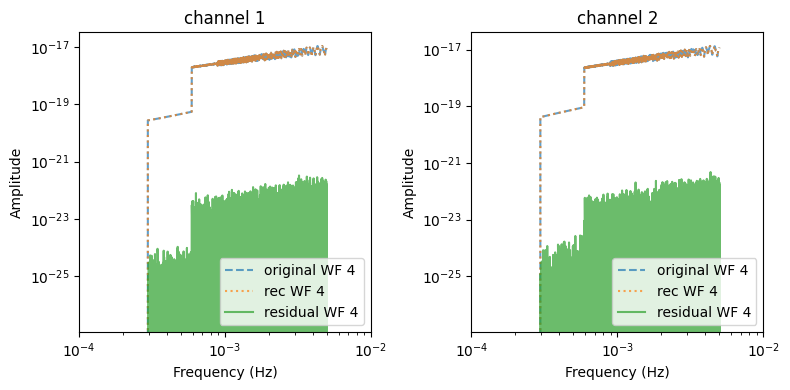

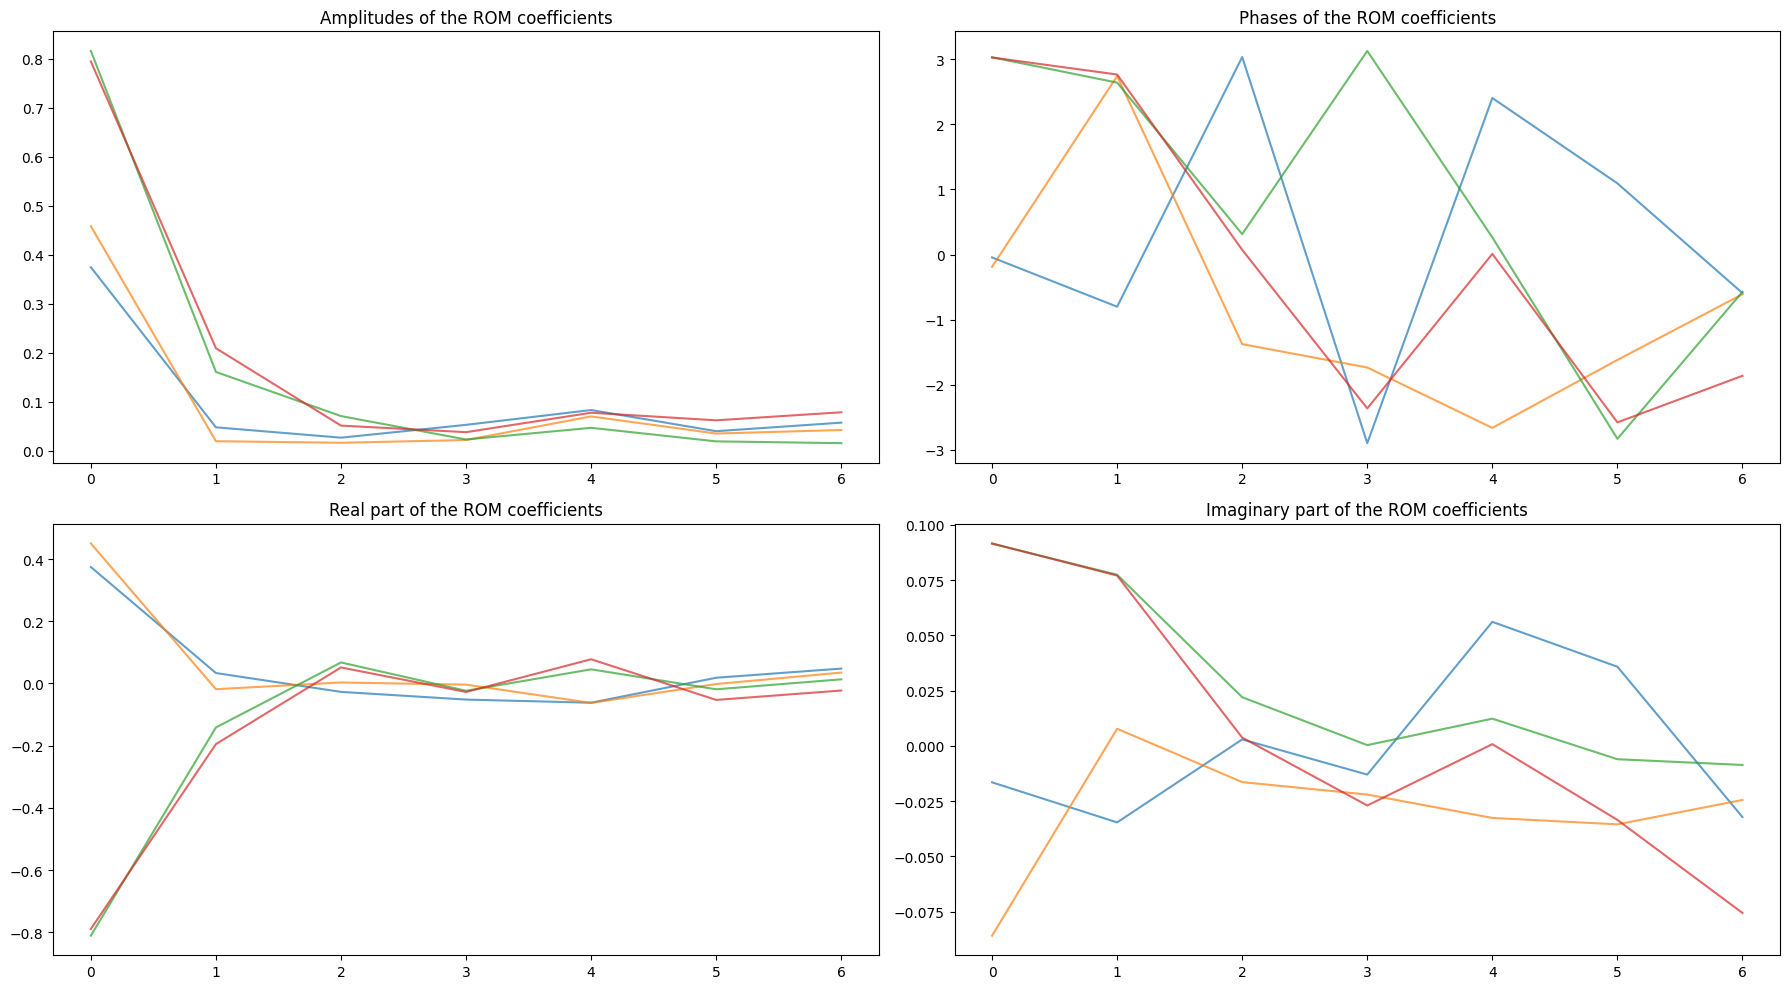

In [38]:
n_channels = rom.n_channels
N_events_plot = 4
for j in range(N_events_plot):
    fig, ax = plt.subplots(1,n_channels, figsize=(8, 4))   
    for i in range(n_channels):
        print(f"mean of channel {i}, event {j}: {torch.mean(wave_fd[j,i,:]).item():.3e}\n std: {torch.std(wave_fd[j,i,:]).item():.3e}")
        #ax[0].plot(freqs, data_fd[j,i,:].numpy(), label=f'original data {j+1}', alpha=0.7) 
        ax[i].plot(freqs, amplitudes_wave[j,i,:].numpy(), '--', label=f'original WF {j+1}', alpha=0.7)
        #ax[1].plot(freqs, reconstructed_logamplitudes_data[j,i,:].numpy(), '--', label=f'rec data {j+1}', alpha=0.7)
        ax[i].plot(freqs, reconstructed_amplitudes[j,i,:].numpy(), ':', label=f'rec WF {j+1}', alpha=0.7)
        ax[i].plot(freqs, amplitudes_wave[j,i,:].numpy()-reconstructed_amplitudes[j,i,:].numpy(), '-', label=f'residual WF {j+1}', alpha=0.7)
        ax[i].set_title(f'channel {i+1}')
        ax[i].set_ylabel('Amplitude')
        ax[i].set_xscale("log")
        ax[i].legend()
        ax[i].set_yscale("log")
        ax[i].set_xlabel('Frequency (Hz)')
        ax[i].set_xlim(1e-4, 1e-2)

    
    fig.savefig(os.path.join(plot_dir, f"rom_amplitudes_event_{j+1}.png"), dpi=150)
    plt.tight_layout()

# plot the abs , phase, re and im of the coeffs for N_events_plot events: 
fig, ax = plt.subplots(2, 2, figsize=(18, 10))
for j in range(N_events_plot):
    ax[0, 0].plot(torch.abs(coeffs_data[j,:]).cpu().numpy(), label=f'ev {j+1}', alpha=0.7)
    ax[0, 1].plot(torch.angle(coeffs_data[j,:]).cpu().numpy(), label=f'ev {j+1}', alpha=0.7)
    ax[1, 0].plot(coeffs_data[j,:].real.cpu().numpy(), label=f'ev {j+1}', alpha=0.7)
    ax[1, 1].plot(coeffs_data[j,:].imag.cpu().numpy(), label=f'ev {j+1}', alpha=0.7)
ax[0, 0].set_title('Amplitudes of the ROM coefficients')
ax[0, 1].set_title('Phases of the ROM coefficients')
ax[1, 0].set_title('Real part of the ROM coefficients')
ax[1, 1].set_title('Imaginary part of the ROM coefficients')
plt.tight_layout()

#### plot reconstructed vs original data for a few examples 


mean of channel 0, event 0: -4.692e-21-1.634e-21j
 std: 5.990e-18
mean of channel 1, event 0: -1.035e-21+5.635e-21j
 std: 7.157e-18
mean of channel 0, event 1: -4.704e-21-1.593e-21j
 std: 5.990e-18
mean of channel 1, event 1: -9.864e-22+5.641e-21j
 std: 7.157e-18
mean of channel 0, event 2: -4.390e-21-2.378e-21j
 std: 5.991e-18
mean of channel 1, event 2: -1.937e-21+5.436e-21j
 std: 7.158e-18
mean of channel 0, event 3: -4.393e-21-2.373e-21j
 std: 5.991e-18
mean of channel 1, event 3: -1.931e-21+5.438e-21j
 std: 7.158e-18


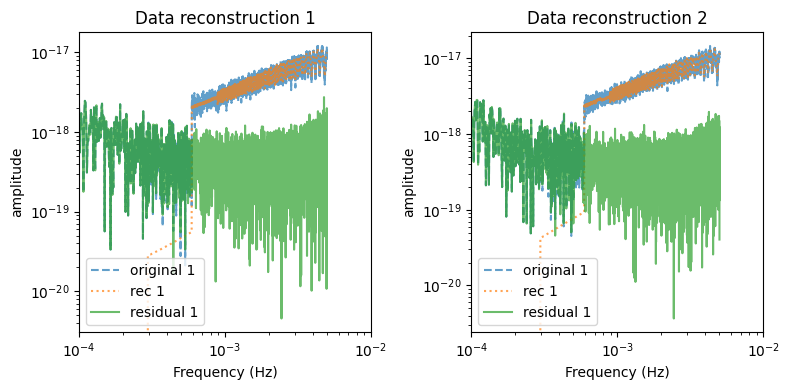

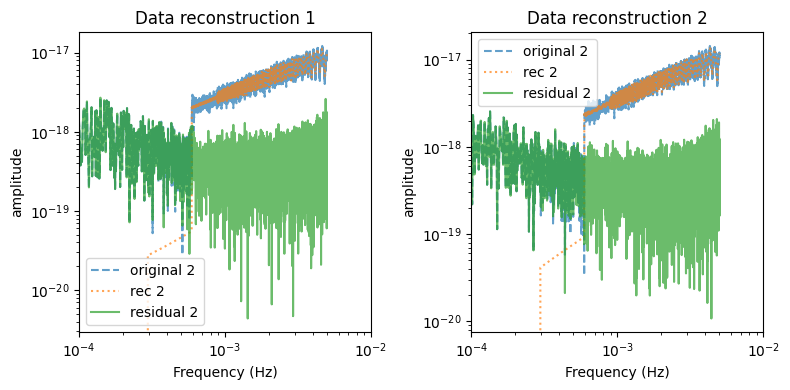

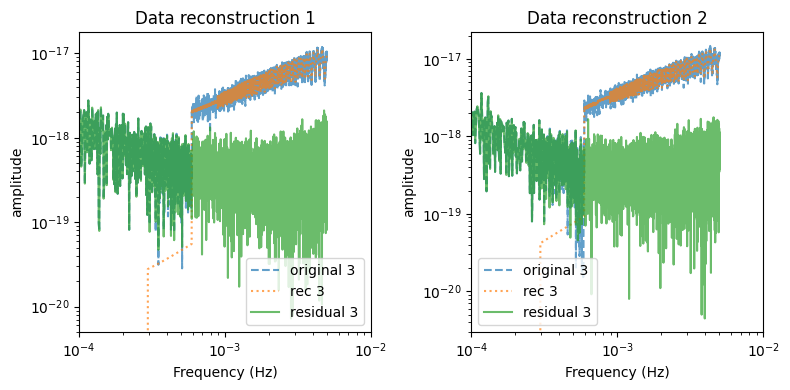

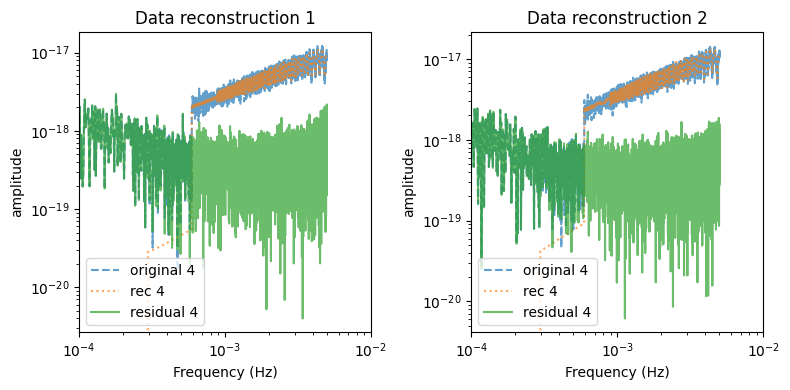

In [39]:
n_channels = rom.n_channels
N_events_plot = 4
for j in range(N_events_plot):
    fig, ax = plt.subplots(1,n_channels, figsize=(8, 4))   
    for i in range(n_channels):
        print(f"mean of channel {i}, event {j}: {torch.mean(wave_fd[j,i,:]).item():.3e}\n std: {torch.std(wave_fd[j,i,:]).item():.3e}")
        #ax[0].plot(freqs, data_fd[j,i,:].numpy(), label=f'original data {j+1}', alpha=0.7) 
        ax[i].plot(freqs, amplitudes_data[j,i,:].numpy(), '--', label=f'original {j+1}', alpha=0.7)
        #ax[1].plot(freqs, reconstructed_logamplitudes_data[j,i,:].numpy(), '--', label=f'rec data {j+1}', alpha=0.7)
        ax[i].plot(freqs, reconstructed_amplitudes_data[j,i,:].numpy(), ':', label=f'rec {j+1}', alpha=0.7)
        ax[i].plot(freqs, (data_fd[j,i,:]-reconstructed_data[j,i,:]).abs().cpu().numpy(), '-', label=f'residual {j+1}', alpha=0.7)
        ax[i].set_title(f'Data reconstruction {i+1}')
        ax[i].set_ylabel('amplitude')
        ax[i].set_xscale("log")
        ax[i].legend()
        ax[i].set_yscale("log")
        ax[i].set_xlabel('Frequency (Hz)')
        ax[i].set_xlim(1e-4, 1e-2)

    
    fig.savefig(os.path.join(plot_dir, f"rom_amplitudes_event_{j+1}.png"), dpi=150)
    plt.tight_layout()

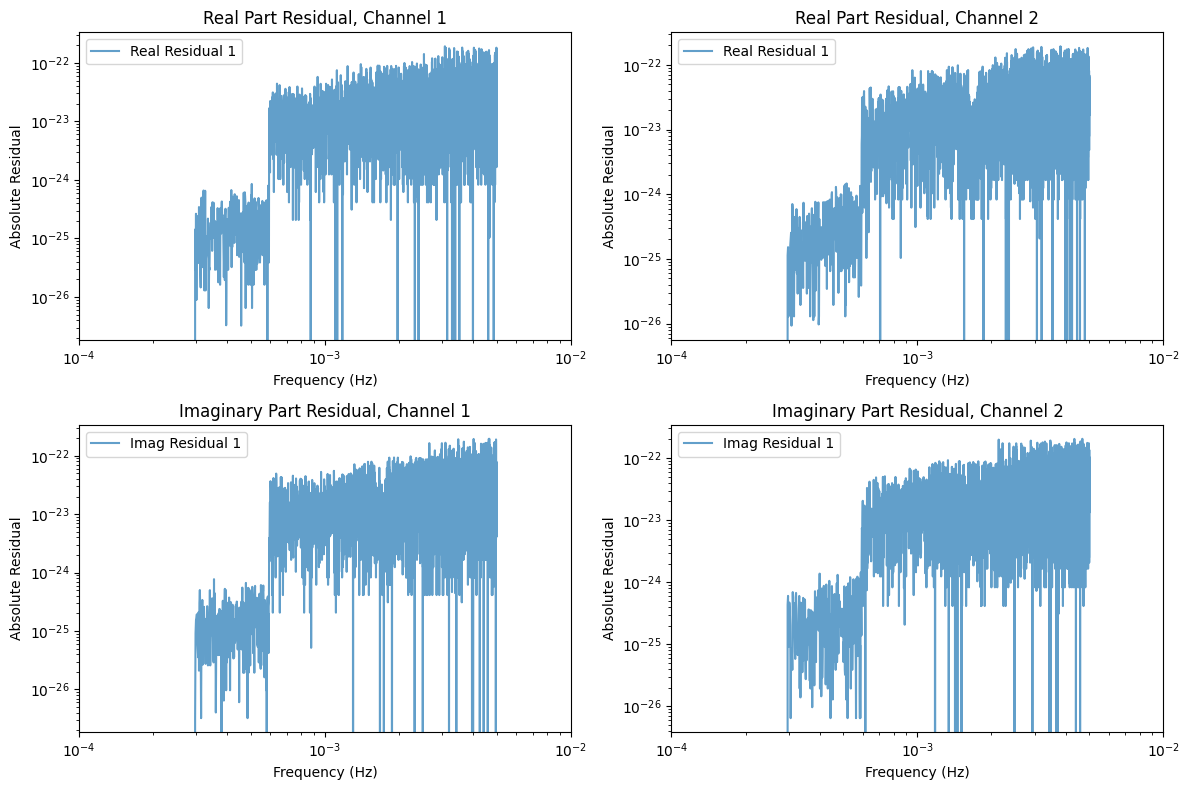

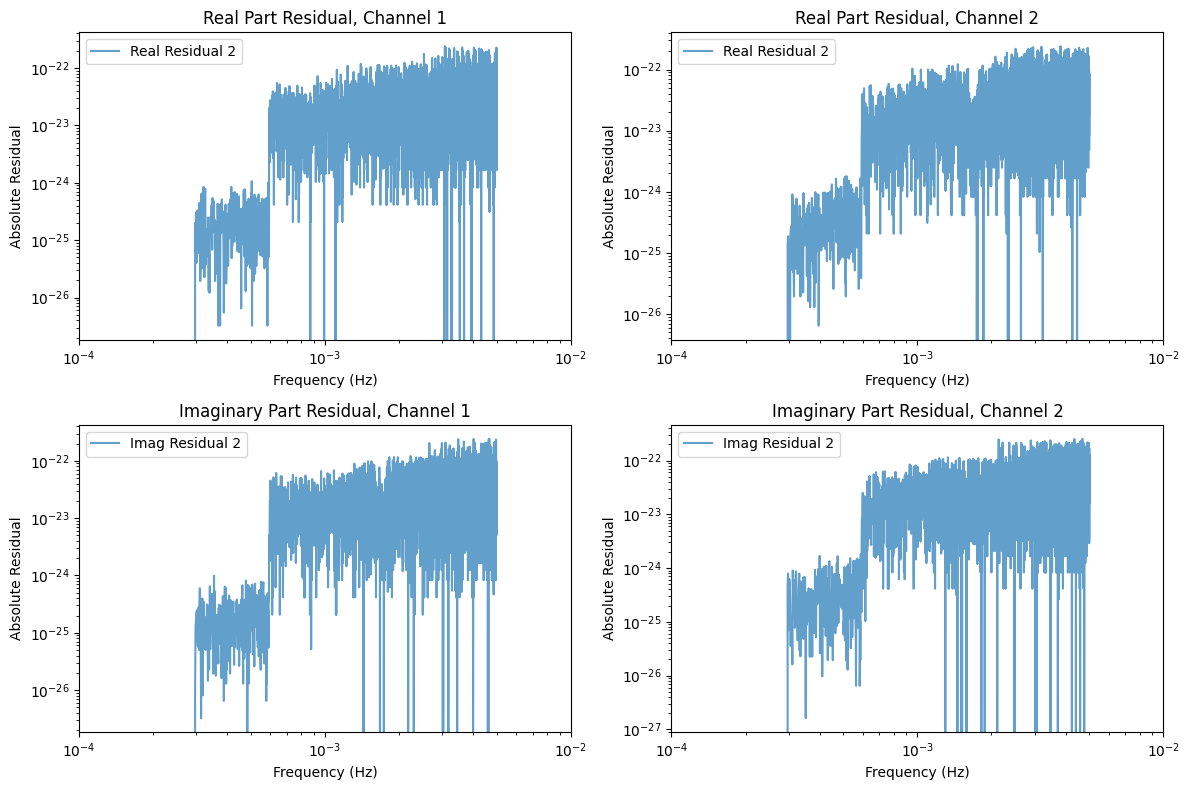

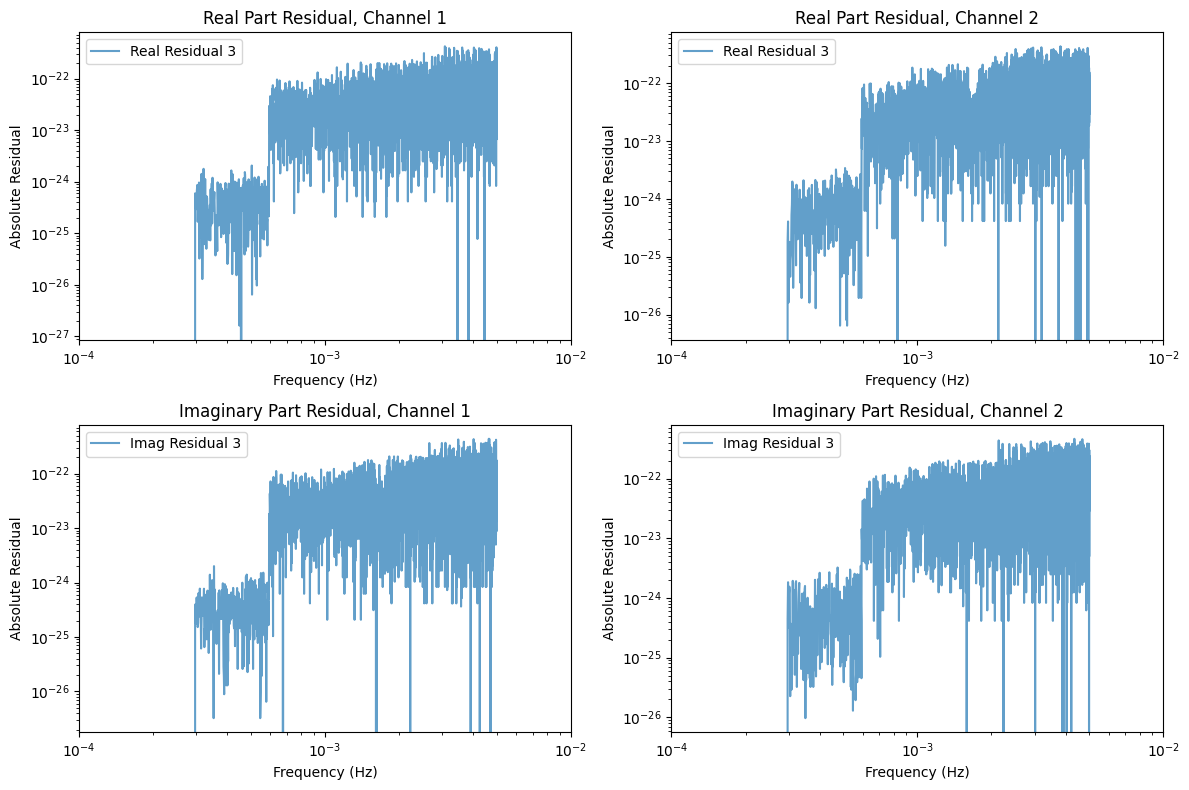

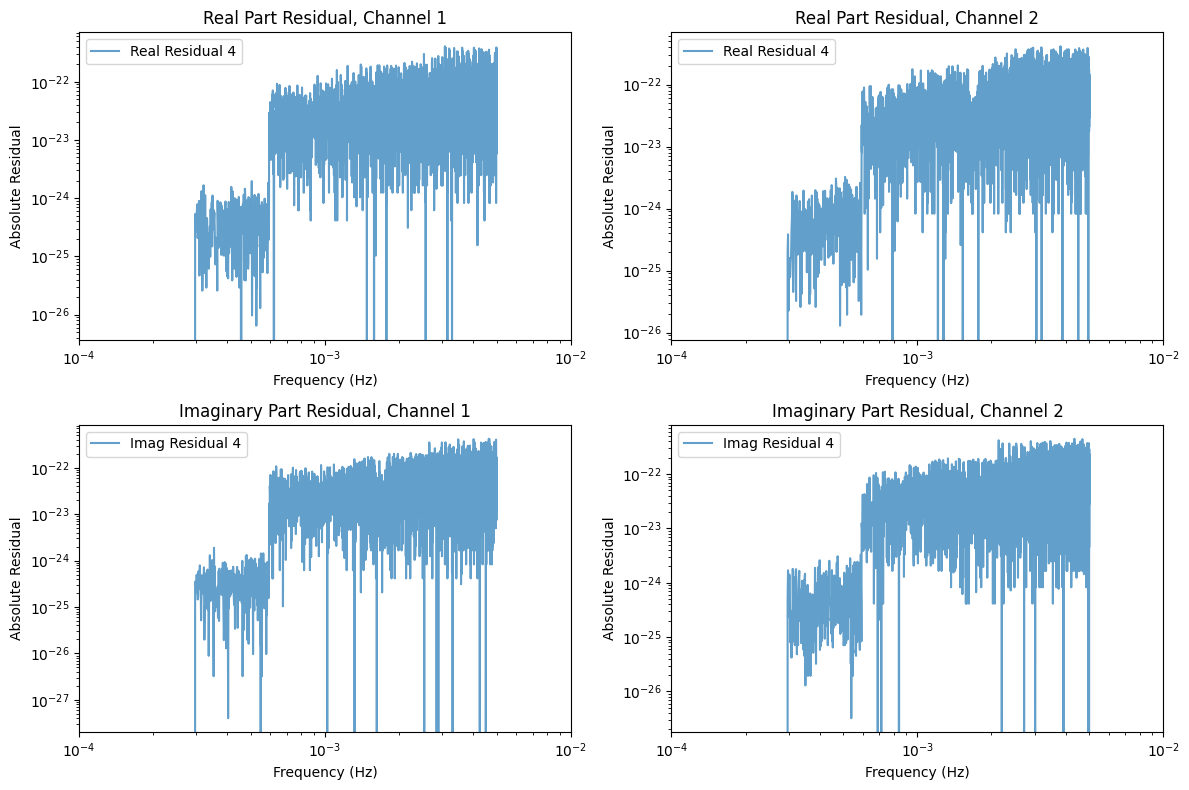

In [40]:
# Plot absolute residuals for real and imaginary parts of the waveform
n_channels = rom.n_channels
N_events_plot = 4
for j in range(N_events_plot):
    fig, ax = plt.subplots(2, n_channels, figsize=(12, 8))
    for i in range(n_channels):
        # Real part residual
        ax[0, i].plot(freqs, (wave_fd[j, i, :].real - reconstructed_wave[j, i, :].real).abs().numpy(), '-', label=f'Real Residual {j+1}', alpha=0.7)
        ax[0, i].set_title(f'Real Part Residual, Channel {i+1}')
        ax[0, i].set_ylabel('Absolute Residual')
        ax[0, i].set_xscale("log")
        ax[0, i].set_yscale("log")
        ax[0, i].legend()
        ax[0, i].set_xlabel('Frequency (Hz)')
        ax[0, i].set_xlim(1e-4, 1e-2)

        # Imaginary part residual
        ax[1, i].plot(freqs, (wave_fd[j, i, :].imag - reconstructed_wave[j, i, :].imag).abs().numpy(), '-', label=f'Imag Residual {j+1}', alpha=0.7)
        ax[1, i].set_title(f'Imaginary Part Residual, Channel {i+1}')
        ax[1, i].set_ylabel('Absolute Residual')
        ax[1, i].set_xscale("log")
        ax[1, i].set_yscale("log")
        ax[1, i].legend()
        ax[1, i].set_xlabel('Frequency (Hz)')
        ax[1, i].set_xlim(1e-4, 1e-2)

    plt.tight_layout()
    plt.show()

mean of channel 0, event 0: -4.692e-21-1.634e-21j
 std: 5.990e-18
mean of channel 1, event 0: -1.035e-21+5.635e-21j
 std: 7.157e-18
mean of channel 0, event 1: -4.704e-21-1.593e-21j
 std: 5.990e-18
mean of channel 1, event 1: -9.864e-22+5.641e-21j
 std: 7.157e-18
mean of channel 0, event 2: -4.390e-21-2.378e-21j
 std: 5.991e-18
mean of channel 1, event 2: -1.937e-21+5.436e-21j
 std: 7.158e-18
mean of channel 0, event 3: -4.393e-21-2.373e-21j
 std: 5.991e-18
mean of channel 1, event 3: -1.931e-21+5.438e-21j
 std: 7.158e-18


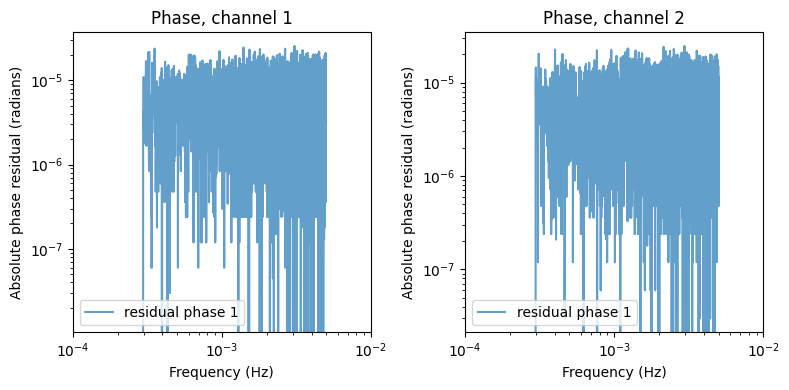

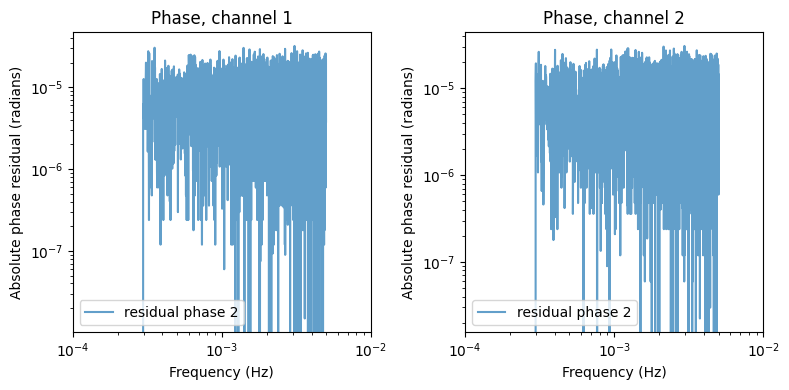

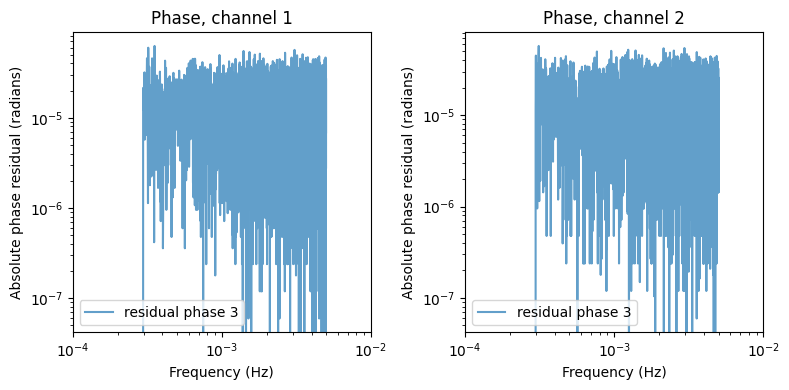

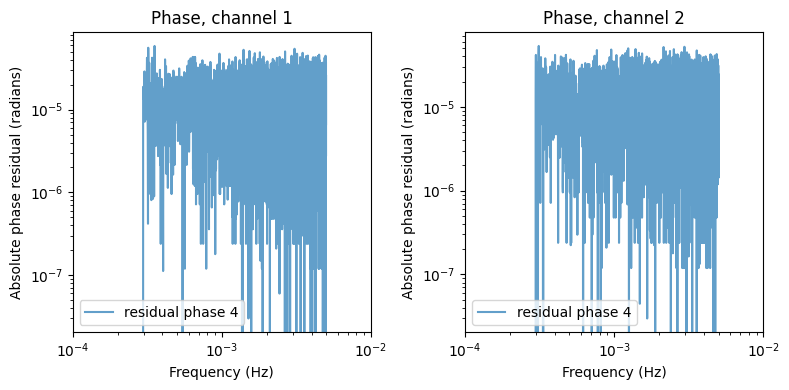

In [41]:
# plot difference in phases between original and reconstructed waveforms : 
n_channels = rom.n_channels
N_events_plot = 4
for j in range(N_events_plot):
    fig, ax = plt.subplots(1, n_channels, figsize=(8, 4))
    for i in range(n_channels):
        print(f"mean of channel {i}, event {j}: {torch.mean(wave_fd[j, i, :]).item():.3e}\n std: {torch.std(wave_fd[j, i, :]).item():.3e}")
        # ax[i].plot(freqs, phases_wave[j, i, :].numpy(), '--', label=f'original WF {j+1}', alpha=0.7)
        # ax[i].plot(freqs, reconstructed_phases_wave[j, i, :].numpy(), ':', label=f'rec WF {j+1}', alpha=0.7)
        ax[i].plot(freqs, (phases_wave[j, i, :] - reconstructed_phases_wave[j, i, :]).abs().numpy(), '-', label=f'residual phase {j+1}', alpha=0.7)
        ax[i].set_title(f'Phase, channel {i+1}')
        ax[i].set_ylabel('Absolute phase residual (radians)')
        ax[i].set_xscale("log")
        ax[i].set_yscale("log")
        ax[i].legend()
        ax[i].set_xlabel('Frequency (Hz)')
        ax[i].set_xlim(1e-4, 1e-2)

    plt.tight_layout()

#### plot variation in signal with varying parameters...

In [59]:
from torch.utils.data import Subset, DataLoader
from pembhb.data import MBHBDataModule
# importlib.reload(pembhb_data)
import importlib 
import torch
import numpy as np
import matplotlib.pyplot as plt

In [54]:
fix_q_filename = "/data/gpuleo/mbhb/fix_q_vary_mc_ok.h5"
datamodule = MBHBDataModule(fix_q_filename, batch_size=100, num_workers=2, cache_in_memory=False)
datamodule.setup(stage="test")
dataloader = datamodule.test_dataloader()

for idx, batch in enumerate(dataloader): 
    data_fd_fixq = batch["wave_fd"]+batch["noise_fd"]  # shape (B, 2*ch, n_freq),  has amplitude and phase
    wave_fd_fixq = batch["wave_fd"]  # shape (B, ch, n_freq), contains complex numbers 
    params_fixq =  batch["source_parameters"][:,:2]  # shape (B, 2)

print(data_fd_fixq.shape)

torch.Size([100, 2, 4096])


In [60]:
fix_mc_filename = "/data/gpuleo/mbhb/fix_mc_vary_q_ok.h5"
datamodule = MBHBDataModule(fix_mc_filename, batch_size=100, num_workers=2, cache_in_memory=False)
datamodule.setup(stage="test")
dataloader = datamodule.test_dataloader()

for idx, batch in enumerate(dataloader): 
    data_fd_fixmc = batch["wave_fd"]+batch["noise_fd"]  # shape (B, 2*ch, n_freq),  has amplitude and phase
    wave_fd_fixmc = batch["wave_fd"]  # shape (B, ch, n_freq), contains complex numbers 
    params_fixmc = batch["source_parameters"][:,:2]  # shape (B, 2)

print(data_fd_fixmc.shape)

torch.Size([100, 2, 4096])


In [58]:
print(torch.set_printoptions(precision=8))
print(params_fixq)

None
tensor([[5.26632404, 4.68375015],
        [5.26631784, 4.68375015],
        [5.26630783, 4.68375015],
        [5.26631737, 4.68375015],
        [5.26635599, 4.68375015],
        [5.26633883, 4.68375015],
        [5.26638794, 4.68375015],
        [5.26639557, 4.68375015],
        [5.26639032, 4.68375015],
        [5.26639557, 4.68375015],
        [5.26635981, 4.68375015],
        [5.26632547, 4.68375015],
        [5.26639605, 4.68375015],
        [5.26635408, 4.68375015],
        [5.26635361, 4.68375015],
        [5.26633072, 4.68375015],
        [5.26638174, 4.68375015],
        [5.26638937, 4.68375015],
        [5.26631117, 4.68375015],
        [5.26635075, 4.68375015],
        [5.26638126, 4.68375015],
        [5.26635122, 4.68375015],
        [5.26637745, 4.68375015],
        [5.26631117, 4.68375015],
        [5.26636171, 4.68375015],
        [5.26639032, 4.68375015],
        [5.26638079, 4.68375015],
        [5.26638699, 4.68375015],
        [5.26633406, 4.68375015],
        [

In [62]:
# take the middle point for the chirp mass: 
middle_mc = 5.26635
idx_middle = (torch.argmin(torch.abs(params_fixq[:,0]- middle_mc)))
print(idx_middle, params_fixq[idx_middle,:])


tensor(19) tensor([5.26635075, 4.68375015])


In [63]:
reference_wave = wave_fd_fixq[idx_middle:idx_middle+1,:,:]
reldist_ref_fix_q = np.linalg.norm( wave_fd_fixq - reference_wave, axis=(1,2))/ np.linalg.norm(reference_wave, axis=(1,2))
reldist_ref_fix_mc = np.linalg.norm( wave_fd_fixmc - reference_wave, axis=(1,2))/ np.linalg.norm(reference_wave, axis=(1,2))

In [64]:

print(reference_wave.shape, wave_fd_fixq.shape)

torch.Size([1, 2, 4096]) torch.Size([100, 2, 4096])


In [65]:
sort_fixq_by_mc = torch.argsort(params_fixq[:,0])
sort_fixmc_by_q = torch.argsort(params_fixmc[:,1])

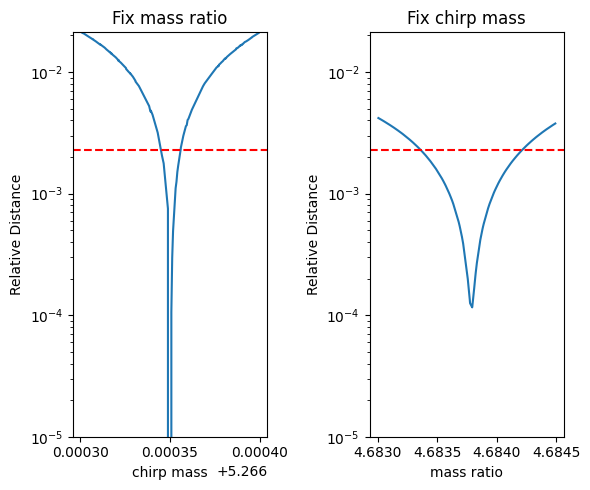

In [154]:
shared_ylim = (1e-5, max(reldist_ref_fix_q.max(), reldist_ref_fix_mc.max()))
plt.figure(figsize=(6,5))
plt.subplot(1,2,1)
plt.plot(params_fixq[sort_fixq_by_mc,0], reldist_ref_fix_q[sort_fixq_by_mc])
plt.xlabel("chirp mass")
plt.title("Fix mass ratio")
plt.ylabel("Relative Distance")
plt.axhline(mean_relerr_datawave, color='r', linestyle='--')
plt.yscale("log")
plt.ylim(shared_ylim)
plt.subplot(1,2,2)
plt.plot(params_fixmc[sort_fixmc_by_q,1], reldist_ref_fix_mc[sort_fixmc_by_q])
plt.axhline(mean_relerr_datawave, color='r', linestyle='--')
plt.title("Fix chirp mass")
plt.xlabel("mass ratio")
plt.ylabel("Relative Distance")
plt.yscale("log")
plt.ylim(shared_ylim)
plt.tight_layout()

plt.show()

In [153]:
print(shared_ylim)

(np.float32(0.0), np.float32(0.0212063))


### chi square test to convince Rob

In [112]:
# import the power spectral density used to generate the data
import h5py 
with h5py.File(data_filename, 'r') as f:
    asd = f['asd'][:]
    psd = asd**2
    freqs = f["frequencies"][:]

### apply the same filter that was used to generate the noise in the data
filtered_freqs_indices = np.argwhere((freqs > 5e-5)).reshape(-1)
psd_torch = torch.Tensor(psd)
df = freqs[1]-freqs[0]

In [207]:
residual_data = reconstructed_data - data_fd 
numerator = (  residual_data.conj() * residual_data )
variance = psd_torch / (4*df) 
print(variance.shape)

# retain only the frequencies that have been low passed
num_filtered = numerator[:,:,filtered_freqs_indices]
variance_filtered = variance[:,filtered_freqs_indices]
# filtered_numerator = numerator
normalised_residual = ( num_filtered ) / variance_filtered
chi_square = torch.sum( normalised_residual, dim=(1,2))
Ndof = filtered_freqs_indices.shape[0]*rom.n_channels*2  # factor 2 for re and im parts
print(f"n dof: {Ndof}, len filtered freqs: {len(filtered_freqs_indices)}")

torch.Size([2, 4096])
n dof: 16224, len filtered freqs: 4056


/u/g/gpuleo/miniconda3/envs/lisa/lib/python3.13/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/u/g/gpuleo/miniconda3/envs/lisa/lib/python3.13/site-packages/numpy/lib/_histograms_impl.py:853: ComplexWarning: Casting complex values to real discards the imaginary part
  indices = f_indices.astype(np.intp)
/u/g/gpuleo/miniconda3/envs/lisa/lib/python3.13/site-packages/numpy/lib/_histograms_impl.py:896: ComplexWarning: Casting complex values to real discards the imaginary part
  db = np.array(np.diff(bin_edges), float)
/u/g/gpuleo/miniconda3/envs/lisa/lib/python3.13/site-packages/matplotlib/axes/_axes.py:7135: ComplexWarning: Casting complex values to real discards the imaginary part
  bins = np.array(bins, float)  # causes problems if float16


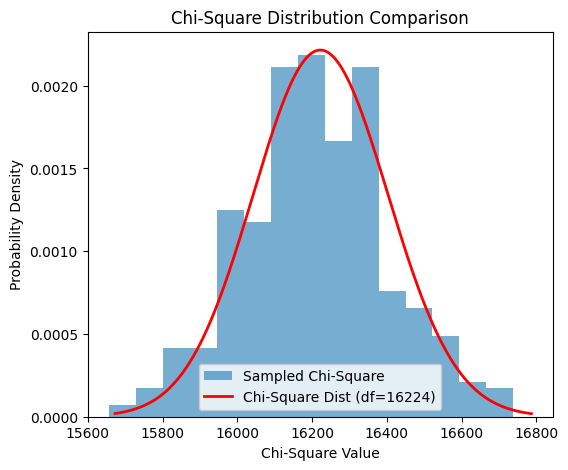

In [208]:
#compare the distribution of chi_square samples with the chi square distribution with Ndof degrees of freedom
from scipy.stats import chi2
chi2_dist = chi2(df=Ndof)
x = np.linspace(chi2_dist.ppf(0.001), chi2_dist.ppf(0.999), 1000)
plt.figure(figsize=(6,5))
plt.hist(chi_square.cpu().numpy(), bins=15, density=True, alpha=0.6, label='Sampled Chi-Square')
plt.plot(x, chi2_dist.pdf(x), 'r-', lw=2, label=f'Chi-Square Dist (df={Ndof})')
plt.xlabel('Chi-Square Value')
plt.ylabel('Probability Density')
plt.title('Chi-Square Distribution Comparison')
plt.legend()
plt.show()

(array([ 3., 10., 14., 14., 12., 13., 19.,  6.,  6.,  3.]),
 array([0.0920404 , 0.0924638 , 0.0928872 , 0.09331061, 0.09373401,
        0.09415741, 0.09458081, 0.09500422, 0.09542762, 0.09585103,
        0.09627443]),
 <BarContainer object of 10 artists>)

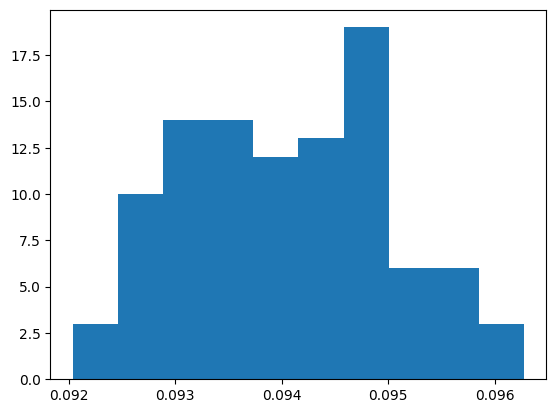

In [137]:
####
plt.hist(relative_errors_data)

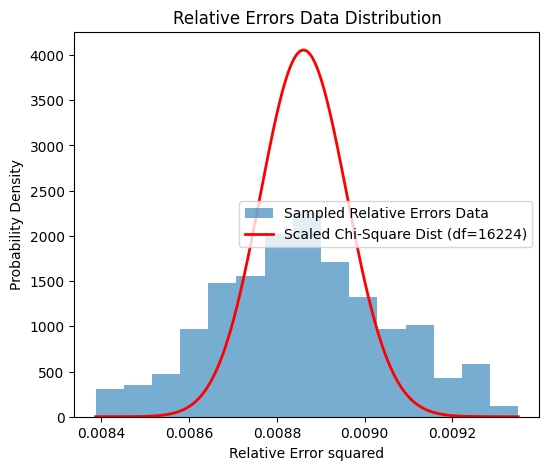

In [210]:
mean_psd = torch.mean(psd_torch[:, filtered_freqs_indices])
sigma_bar2 = mean_psd / (4*df)
mean_data_square_norm = torch.mean( torch.linalg.norm(data_fd[:,:,filtered_freqs_indices], dim=(1,2))**2, dim=0 )
## relative_errors_data is roughly distributed as a random variable x = mean_psd / mean_data_square_norm * chi2(df=Ndof)
scaling_factor = sigma_bar2 / mean_data_square_norm
# plot the histogram of relative_errors_data and overlay the scaled chi2 distribution
plt.figure(figsize=(6,5))
plt.hist(relative_errors_data**2, bins=15, density=True, alpha=0.6, label='Sampled Relative Errors Data')
x = np.linspace(np.min(relative_errors_data**2), np.max(relative_errors_data**2), 1000)

# should_be_chi2 = relative_errors_data**2 / scaling_factor 
# plt.figure(figsize=(6,5))
# plt.hist(should_be_chi2, bins=15, density=True, alpha=0.6, label='Scaled Relative Errors Data')
plt.plot(x, chi2_dist.pdf(x / scaling_factor)/scaling_factor, 'r-', lw=2, label=f'Scaled Chi-Square Dist (df={Ndof})')
plt.xlabel('Relative Error squared')
plt.ylabel('Probability Density')
plt.title('Relative Errors Data Distribution')
plt.legend()
plt.show()